In [14]:
#Necessary imports and configuration
# YOLO v1 from Scratch (MNIST Digit Detection)
# Faithfully mimicking Redmon et al. 2016
# This run uses Fast YOLO (9 conv layers) as described
# in the original paper as a speed optimised variant considering our dataset i.e mnist one is compartively small 

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# YOLO v1 grid parameters, paper Section 2, do not change
S = 7    # 7x7 grid
B = 2    # 2 bounding boxes per cell
C = 10   # 10 classes for MNIST digits 0-9

# Loss weights from paper Section 3
# lambda_coord=5 penalises localisation errors more
# lambda_noobj=0.5 down-weights empty cell confidence
# kept at paper values for this run
LAMBDA_COORD  = 5.0
LAMBDA_NOOBJ  = 0.5

# Image and scene config
IMG_SIZE      = 448   # standard YOLO input resolution
DIGIT_SIZE    = 48    # MNIST digits resized to 48x48
                      # matches pretraining scale exactly
MIN_DIGITS    = 1   # minimum digits per scene
MAX_DIGITS    = 8     # maximum digits per scene

# Training config
# LR=1e-3 used instead of paper's 1e-2 since higher LR
# caused degenerate boxes on small synthetic dataset
# documented in Run 6 of ablation study
BATCH_SIZE    = 16
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 5e-3   # increased from paper's 5e-4
                        # to reduce overfitting on small dataset
MOMENTUM      = 0.9

# Paths
DATA_DIR  = "/kaggle/working/data"
CKPT_DIR  = "/kaggle/working/checkpoints"
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR,  exist_ok=True)

print(f"  Fast YOLO — MNIST Digit Detection")
print(f"  Architecture : 9 conv layers, paper Fast YOLO variant")
print(f"  Grid         : {S}x{S}  |  Boxes/cell: {B}  |  Classes: {C}")
print(f"  Output       : {S}x{S}x{B*5+C}")
print(f"  lambda_coord : {LAMBDA_COORD}  |  lambda_noobj: {LAMBDA_NOOBJ}")
print(f"  LR           : {LEARNING_RATE}  |  WD: {WEIGHT_DECAY}")

# LR schedule faithful to paper Section 4
# milestones scaled from paper's 75/105/135 to our 30 epoch budget
# 75/135*30=17 and 105/135*30=23
def get_lr_schedule(optimizer):
    return optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones = [17, 23],
        gamma      = 0.1
    )

Using device: cuda
  Fast YOLO — MNIST Digit Detection
  Architecture : 9 conv layers, paper Fast YOLO variant
  Grid         : 7x7  |  Boxes/cell: 2  |  Classes: 10
  Output       : 7x7x20
  lambda_coord : 5.0  |  lambda_noobj: 0.5
  LR           : 0.001  |  WD: 0.005


Generating synthetic MNIST detection scenes...
Image tensor   : (1, 448, 448)  range=[0.00, 0.73]
Label tensor   : (7, 7, 20)
Occupied cells : 7
Train scenes   : 16000
Val scenes     : 3200


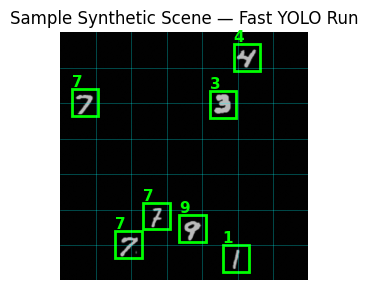

In [34]:
#Synthetic Dataset Generator
# Creates multi-digit MNIST scenes that mimic a real detection dataset.
# Each scene places 3 to 8 MNIST digits randomly on a 448x448 canvas
# with rejection sampling to avoid overlaps between digits.
# Labels are encoded in YOLO v1 format exactly as described in paper
# Section 2: x,y as cell-relative offsets, w,h as image fractions. ( i took the terms as is)
# Data augmentation matches paper Section 4: brightness and contrast
# jitter as greyscale equivalent of HSV exposure and saturation.

class SyntheticMNISTDataset(Dataset):
    """
    Generates synthetic detection scenes from raw MNIST digits.

    Each sample returns:
        image  : (1, 448, 448) float tensor normalised to [0, 1]
        label  : (S, S, B*5+C) float tensor in YOLO v1 format

    Label encoding per cell follows paper Section 2:
        x, y  : center offset relative to cell top-left, in [0, 1]
        w, h  : box size as fraction of full image, in [0, 1]
        conf  : 1.0 if object assigned to this cell, else 0.0
        class : one-hot vector of length C
    """

    def __init__(self, mnist_root, train=True, num_samples=8000,
                 img_size=448, digit_size=48,
                 min_digits=3, max_digits=8,
                 S=7, B=2, C=10, seed=42, augment=False):

        self.img_size    = img_size
        self.digit_size  = digit_size
        self.min_digits  = min_digits
        self.max_digits  = max_digits
        self.num_samples = num_samples
        self.S           = S
        self.B           = B
        self.C           = C
        self.cell_size   = img_size / S
        self.augment     = augment

        # Load raw MNIST
        mnist             = MNIST(root=mnist_root, train=train,
                                   download=True)
        self.mnist_images = mnist.data.numpy()
        self.mnist_labels = mnist.targets.numpy()

        # Group indices by class for balanced sampling
        self.class_indices = {
            c: np.where(self.mnist_labels == c)[0]
            for c in range(C)
        }

        # Pre-generate all scene layouts so they are consistent
        # across epochs, same scene always has same digits and positions
        rng         = np.random.RandomState(seed)
        self.scenes = [self._sample_scene(rng)
                       for _ in range(num_samples)]

        self.to_tensor = transforms.ToTensor()

        # Augmentation matching paper Section 4
        # brightness and contrast jitter as greyscale equivalent
        # of paper's random exposure and saturation in HSV space
        # applied to training only, not validation
        self.augment_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ColorJitter(
                brightness = 0.5,
                contrast   = 0.5,
            ),
            transforms.ToTensor(),
        ])

    def _sample_scene(self, rng):
        """
        Randomly decide which digits go where in this scene.
        Uses rejection sampling so no two digits overlap at all.
        Returns a list of placement dicts with mnist index,
        class label, and pixel bounding box coordinates.
        """
        n          = rng.randint(self.min_digits, self.max_digits + 1)
        placements = []
        tries      = 0

        while len(placements) < n and tries < 200:
            tries += 1
            cls    = rng.randint(0, self.C)
            idx    = self.class_indices[cls][
                         rng.randint(0, len(self.class_indices[cls]))]
            x1     = rng.randint(0, self.img_size - self.digit_size)
            y1     = rng.randint(0, self.img_size - self.digit_size)
            x2     = x1 + self.digit_size
            y2     = y1 + self.digit_size

            overlap = False
            for p in placements:
                ix1 = max(x1, p['x1']); iy1 = max(y1, p['y1'])
                ix2 = min(x2, p['x2']); iy2 = min(y2, p['y2'])
                if ix2 > ix1 and iy2 > iy1:
                    overlap = True
                    break

            if not overlap:
                placements.append(dict(mnist_idx=idx, cls=cls,
                                       x1=x1, y1=y1, x2=x2, y2=y2))
        return placements

    def _build_label(self, placements):
        """
        Convert placement list into a (S, S, B*5+C) label tensor.
        For each digit find its responsible grid cell:
            col = floor(cx_normalised * S)
            row = floor(cy_normalised * S)
        Store cell-relative x,y offset and image-normalised w,h
        in both B box slots. Responsible box selected by IoU
        during loss computation, matching paper Section 3.
        If two digits land in the same cell the second is skipped,
        enforcing the paper's one-object-per-cell constraint.
        """
        label = torch.zeros(self.S, self.S, 5 * self.B + self.C)

        for p in placements:
            cx  = (p['x1'] + p['x2']) / 2.0 / self.img_size
            cy  = (p['y1'] + p['y2']) / 2.0 / self.img_size
            w   = self.digit_size / self.img_size
            h   = self.digit_size / self.img_size

            col = min(int(cx * self.S), self.S - 1)
            row = min(int(cy * self.S), self.S - 1)

            if label[row, col, 4] == 1.0:
                continue

            x_cell = cx * self.S - col
            y_cell = cy * self.S - row

            for b in range(self.B):
                o = b * 5
                label[row, col, o + 0] = x_cell
                label[row, col, o + 1] = y_cell
                label[row, col, o + 2] = w
                label[row, col, o + 3] = h
                label[row, col, o + 4] = 1.0

            label[row, col, self.B * 5 + p['cls']] = 1.0

        return label

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        placements = self.scenes[idx]

        canvas = np.zeros((self.img_size, self.img_size), dtype=np.uint8)

        for p in placements:
            digit = Image.fromarray(
                        self.mnist_images[p['mnist_idx']]).resize(
                        (self.digit_size, self.digit_size), Image.BILINEAR)
            digit_arr = np.array(digit)
            canvas[p['y1']:p['y2'], p['x1']:p['x2']] = np.maximum(
                canvas[p['y1']:p['y2'], p['x1']:p['x2']], digit_arr)

        if self.augment:
            image = self.augment_transform(canvas)
        else:
            image = self.to_tensor(canvas)

        label = self._build_label(placements)
        return image, label


print("Generating synthetic MNIST detection scenes...")

train_dataset = SyntheticMNISTDataset(
    mnist_root   = DATA_DIR,
    train        = True,
    num_samples  = 16000,
    img_size     = IMG_SIZE,
    digit_size   = DIGIT_SIZE,
    min_digits   = MIN_DIGITS,
    max_digits   = MAX_DIGITS,
    S=S, B=B, C=C,
    seed         = 42,
    augment      = True
)
val_dataset = SyntheticMNISTDataset(
    mnist_root   = DATA_DIR,
    train        = False,
    num_samples  = 3200,
    img_size     = IMG_SIZE,
    digit_size   = DIGIT_SIZE,
    min_digits   = MIN_DIGITS,
    max_digits   = MAX_DIGITS,
    S=S, B=B, C=C,
    seed         = 99,
    augment      = False
)

img, lbl = train_dataset[0]
print(f"Image tensor   : {tuple(img.shape)}  "
      f"range=[{img.min():.2f}, {img.max():.2f}]")
print(f"Label tensor   : {tuple(lbl.shape)}")
print(f"Occupied cells : {(lbl[..., 4] == 1.0).sum().item()}")
print(f"Train scenes   : {len(train_dataset)}")
print(f"Val scenes     : {len(val_dataset)}")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.imshow(img.squeeze(0).numpy(), cmap='gray', vmin=0, vmax=1)
ax.set_title("Sample Synthetic Scene — Fast YOLO Run")

cell_px = IMG_SIZE / S
for i in range(S):
    for j in range(S):
        if lbl[i, j, 4] == 1.0:
            x_cell = lbl[i, j, 0].item()
            y_cell = lbl[i, j, 1].item()
            w_norm = lbl[i, j, 2].item()
            h_norm = lbl[i, j, 3].item()
            cls_id = lbl[i, j, B*5:].argmax().item()
            cx_px  = (j + x_cell) * cell_px
            cy_px  = (i + y_cell) * cell_px
            w_px   = w_norm * IMG_SIZE
            h_px   = h_norm * IMG_SIZE
            rect   = patches.Rectangle(
                (cx_px - w_px/2, cy_px - h_px/2), w_px, h_px,
                linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(cx_px - w_px/2, cy_px - h_px/2 - 4,
                    str(cls_id), color='lime',
                    fontsize=11, fontweight='bold')

for k in range(1, S):
    ax.axhline(k * cell_px, color='cyan', lw=0.4, alpha=0.5)
    ax.axvline(k * cell_px, color='cyan', lw=0.4, alpha=0.5)

ax.axis('off')
plt.tight_layout()
plt.savefig("/kaggle/working/sample_scene_fastyolo.png",
            dpi=120, bbox_inches='tight')
plt.show()

In [16]:
#YOLO v1 Loss Function
# Exact implementation of Equation 3 as in Redmon's et al. 2016
# Unchanged from previous runs, identical for all architecture variants
# Five terms with paper-specified weightings:
#   Term 1: localisation xy, weighted by lambda_coord=5
#   Term 2: localisation wh using sqrt, weighted by lambda_coord=5
#   Term 3: object confidence for responsible box only
#   Term 4: no-object confidence, weighted by lambda_noobj=0.5
#   Term 5: classification loss, only in cells with objects

def compute_iou(pred_boxes, gt_boxes):
    """
    Vectorised IoU between predicted and GT boxes.
    Both inputs shape (..., 4) in [cx, cy, w, h] normalised format.
    Returns IoU tensor of shape (...,).
    """
    p_x1 = pred_boxes[..., 0] - pred_boxes[..., 2] / 2
    p_y1 = pred_boxes[..., 1] - pred_boxes[..., 3] / 2
    p_x2 = pred_boxes[..., 0] + pred_boxes[..., 2] / 2
    p_y2 = pred_boxes[..., 1] + pred_boxes[..., 3] / 2

    g_x1 = gt_boxes[..., 0] - gt_boxes[..., 2] / 2
    g_y1 = gt_boxes[..., 1] - gt_boxes[..., 3] / 2
    g_x2 = gt_boxes[..., 0] + gt_boxes[..., 2] / 2
    g_y2 = gt_boxes[..., 1] + gt_boxes[..., 3] / 2

    inter_x1 = torch.max(p_x1, g_x1)
    inter_y1 = torch.max(p_y1, g_y1)
    inter_x2 = torch.min(p_x2, g_x2)
    inter_y2 = torch.min(p_y2, g_y2)

    inter_area = (inter_x2 - inter_x1).clamp(min=0) * \
                 (inter_y2 - inter_y1).clamp(min=0)

    pred_area  = (p_x2 - p_x1).clamp(min=0) * \
                 (p_y2 - p_y1).clamp(min=0)
    gt_area    = (g_x2 - g_x1).clamp(min=0) * \
                 (g_y2 - g_y1).clamp(min=0)

    union = pred_area + gt_area - inter_area + 1e-8
    return inter_area / union


class YOLOv1Loss(nn.Module):
    """
    Full YOLO v1 loss from Equation 3, Redmon et al. 2016.
    Identical implementation used across all architecture variants.

    Prediction and target tensor layout per cell with B=2, C=10:
        Box 0  indices [0:5]   = [x, y, w, h, conf]
        Box 1  indices [5:10]  = [x, y, w, h, conf]
        Class  indices [10:20] = [p_0 ... p_9]

    Both box slots in GT hold the same ground truth.
    Responsible box selected by highest IoU, paper Section 3.
    """
"""
to note:
This implementation strictly follows YOLOv1 (as perRedmon et al)
Equation (3), including:

1 sum-squared error for all terms
2 sqrt transform for width/height
3 responsibility assignment via highest IoU
4 separate no-object penalty
5 class loss only in object cells

This version is intentionally kept faithful for reproducibility
and direct comparison across Fast YOLO variants.
"""
    def __init__(self, S=7, B=2, C=10,
                 lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S            = S
        self.B            = B
        self.C            = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, predictions, targets):
        N          = predictions.shape[0]
        obj_mask   = targets[..., 4] == 1.0
        noobj_mask = ~obj_mask

        pred_boxes = [predictions[..., b*5 : b*5+4]
                      for b in range(self.B)]
        gt_box     = targets[..., 0:4]

        ious = torch.stack(
            [compute_iou(pred_boxes[b], gt_box)
             for b in range(self.B)], dim=-1)

        _, best_b = ious.max(dim=-1)

        resp_mask = torch.zeros_like(ious, dtype=torch.bool)
        for b in range(self.B):
            resp_mask[..., b] = obj_mask & (best_b == b)

        # Term 1: localisation xy
        loss_xy = torch.tensor(0.0, device=predictions.device)
        for b in range(self.B):
            o    = b * 5
            mask = resp_mask[..., b]
            if mask.any():
                pred_xy = predictions[..., o:o+2][mask]
                gt_xy   = targets[..., 0:2][mask]
                loss_xy = loss_xy + F.mse_loss(pred_xy, gt_xy,
                                               reduction='sum')

        # Term 2: localisation wh with sqrt
        loss_wh = torch.tensor(0.0, device=predictions.device)
        for b in range(self.B):
            o    = b * 5
            mask = resp_mask[..., b]
            if mask.any():
                pred_wh      = predictions[..., o+2:o+4][mask]
                gt_wh        = targets[..., 2:4][mask]
                pred_wh_sqrt = torch.sqrt(pred_wh.clamp(min=1e-8))
                gt_wh_sqrt   = torch.sqrt(gt_wh.clamp(min=1e-8))
                loss_wh      = loss_wh + F.mse_loss(pred_wh_sqrt,
                                                     gt_wh_sqrt,
                                                     reduction='sum')

        # Term 3: object confidence for responsible box
        loss_obj = torch.tensor(0.0, device=predictions.device)
        for b in range(self.B):
            o    = b * 5
            mask = resp_mask[..., b]
            if mask.any():
                pred_conf = predictions[..., o+4][mask]
                iou_score = ious[..., b][mask].detach()
                loss_obj  = loss_obj + F.mse_loss(pred_conf, iou_score,
                                                   reduction='sum')

        # Term 4: no-object confidence
        loss_noobj = torch.tensor(0.0, device=predictions.device)
        for b in range(self.B):
            o          = b * 5
            pred_conf  = predictions[..., o+4][noobj_mask]
            gt_conf    = torch.zeros_like(pred_conf)
            loss_noobj = loss_noobj + F.mse_loss(pred_conf, gt_conf,
                                                  reduction='sum')

        # Term 5: classification, only in object cells
        loss_cls = torch.tensor(0.0, device=predictions.device)
        if obj_mask.any():
            pred_cls = predictions[..., self.B*5:][obj_mask]
            gt_cls   = targets[..., self.B*5:][obj_mask]
            loss_cls = F.mse_loss(pred_cls, gt_cls, reduction='sum')

        total = (self.lambda_coord * (loss_xy + loss_wh)
                 + loss_obj
                 + self.lambda_noobj * loss_noobj
                 + loss_cls) / N

        components = {
            'total' : total.item(),
            'xy'    : (self.lambda_coord * loss_xy / N).item(),
            'wh'    : (self.lambda_coord * loss_wh / N).item(),
            'obj'   : (loss_obj / N).item(),
            'noobj' : (self.lambda_noobj * loss_noobj / N).item(),
            'cls'   : (loss_cls / N).item(),
        }

        return total, components


# Sanity checks
criterion = YOLOv1Loss(S=S, B=B, C=C,
                       lambda_coord=LAMBDA_COORD,
                       lambda_noobj=LAMBDA_NOOBJ).to(DEVICE)

img_t, lbl_t = train_dataset[0]
lbl_t        = lbl_t.unsqueeze(0).to(DEVICE)

loss_perfect, _ = criterion(lbl_t, lbl_t)
print(f"Test 1 perfect prediction : {loss_perfect.item():.6f}  (expect 0)")

rand_pred = torch.randn(1, S, S, B*5+C,
                        requires_grad=True, device=DEVICE)
loss_rand, comps_rand = criterion(rand_pred, lbl_t)
print(f"Test 2 random prediction  : {loss_rand.item():.4f}  (expect >> 0)")

loss_rand.backward()
print(f"Test 3 gradient check     : "
      f"grad not None={rand_pred.grad is not None}  "
      f"norm={rand_pred.grad.norm().item():.4f}")

Test 1 perfect prediction : 0.000000  (expect 0)
Test 2 random prediction  : 257.1470  (expect >> 0)
Test 3 gradient check     : grad not None=True  norm=48.6275


In [33]:
# Fast YOLO Architecture
# Fast YOLO is explicitly described in Redmon et al. 2016 as a
# smaller 9 convolutional layer variant designed for speed.
# Paper: "We also train a fast version of YOLO designed to push
# the boundary of fast object detection."
# All other architectural choices are identical to full YOLOv1:
# LeakyReLU(0.1), no BatchNorm as it wasn't in paper , Dropout(0.5) after FC1,
# linear final output, same FC head with 4096 hidden units.
# Weight init: Kaiming uniform, justified in ablation Run 5 and noted that in our report too
# where paper's normal(0,0.01) caused vanishing gradients.

class CNNBlock(nn.Module):
    """
    Single conv block: Conv2d followed by LeakyReLU(0.1).
    No BatchNorm, faithful to Redmon et al. 2016.
    Kaiming uniform init used instead of paper's normal(0,0.01)
    since normal init caused vanishing gradients at depth.
    """
    def __init__(self, in_ch, out_ch, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, bias=True, **kwargs)
        self.act  = nn.LeakyReLU(0.1, inplace=True)
        nn.init.kaiming_uniform_(self.conv.weight,
                                  mode='fan_in',
                                  nonlinearity='leaky_relu')
        nn.init.zeros_(self.conv.bias)

    def forward(self, x):
        return self.act(self.conv(x))


# Fast YOLO architecture from Redmon et al. 2016
# 9 convolutional layers, fewer filters than full YOLOv1
# designed to be faster while maintaining detection capability
ARCHITECTURE = [
    ("C", 16,   3, 1, 1),
    ("M",),
    ("C", 32,   3, 1, 1),
    ("M",),
    ("C", 64,   3, 1, 1),
    ("M",),
    ("C", 128,  3, 1, 1),
    ("M",),
    ("C", 256,  3, 1, 1),
    ("M",),
    ("C", 512,  3, 1, 1),
    ("M",),
    ("C", 1024, 3, 1, 1),
    ("C", 256,  3, 1, 1),
    ("C", 1024, 3, 1, 1),
]


class YOLOv1(nn.Module):
    """
    Fast YOLO variant from Redmon et al. 2016.
    9 convolutional layers, identical FC head to full YOLOv1.
    Output shape (N, S, S, B*5+C) = (N, 7, 7, 20) unchanged.
    All other architectural choices identical to full YOLOv1.
    """
    def __init__(self, in_channels=1, S=7, B=2, C=10):
        super().__init__()
        self.S, self.B, self.C = S, B, C
        self.backbone = self._build_backbone(in_channels)

        self.fc1  = nn.Linear(1024 * S * S, 4096)
        self.act1 = nn.LeakyReLU(0.1, inplace=True)
        self.drop = nn.Dropout(p=0.5)
        self.fc2  = nn.Linear(4096, S * S * (B * 5 + C))

        nn.init.kaiming_uniform_(self.fc1.weight,
                                  nonlinearity='leaky_relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_uniform_(self.fc2.weight,
                                  nonlinearity='linear')
        nn.init.zeros_(self.fc2.bias)

    def _build_backbone(self, in_channels):
        layers = []
        ch     = in_channels
        for block in ARCHITECTURE:
            if block[0] == "C":
                _, out_ch, k, s, p = block
                layers.append(CNNBlock(ch, out_ch,
                               kernel_size=k, stride=s, padding=p))
                ch = out_ch
            elif block[0] == "M":
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            elif block[0] == "R":
                _, repeated, n = block
                for _ in range(n):
                    for (_, out_ch, k, s, p) in repeated:
                        layers.append(CNNBlock(ch, out_ch,
                                       kernel_size=k, stride=s, padding=p))
                        ch = out_ch
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.backbone(x)
        x = x.flatten(1)
        x = self.drop(self.act1(self.fc1(x)))
        x = self.fc2(x)
        x = x.reshape(-1, self.S, self.S,
                       self.B * 5 + self.C)
        return x


# Verify architecture
model = YOLOv1(in_channels=1, S=S, B=B, C=C).to(DEVICE)

dummy = torch.zeros(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)

print(f"Input  : {tuple(dummy.shape)}")
print(f"Output : {tuple(out.shape)}  (expected (2, {S}, {S}, {B*5+C}))")

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total:,}")
print(f"Trainable params : {train_:,}")

bn_layers   = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]
conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
fc_layers   = [m for m in model.modules() if isinstance(m, nn.Linear)]
print(f"\nBatchNorm layers : {len(bn_layers)}   (must=0)")
print(f"Conv layers      : {len(conv_layers)}  (should be 9 as we are doing fast one)")
print(f"FC layers        : {len(fc_layers)}    (should be 2)")

print("\nFeature map progression:")
x = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    for i, layer in enumerate(model.backbone):
        x = layer(x)
        if isinstance(layer, (CNNBlock, nn.MaxPool2d)):
            t = "Conv+LReLU" if isinstance(layer, CNNBlock) else "MaxPool  "
            print(f"  [{i:02d}] {t} → {tuple(x.shape)}")

Input  : (2, 1, 448, 448)
Output : (2, 7, 7, 20)  (expected (2, 7, 7, 20))

Total params     : 220,552,020
Trainable params : 220,552,020

BatchNorm layers : 0   (must=0)
Conv layers      : 9  (should be 9 as we are doing fast one)
FC layers        : 2    (should be 2)

Feature map progression:
  [00] Conv+LReLU → (1, 16, 448, 448)
  [01] MaxPool   → (1, 16, 224, 224)
  [02] Conv+LReLU → (1, 32, 224, 224)
  [03] MaxPool   → (1, 32, 112, 112)
  [04] Conv+LReLU → (1, 64, 112, 112)
  [05] MaxPool   → (1, 64, 56, 56)
  [06] Conv+LReLU → (1, 128, 56, 56)
  [07] MaxPool   → (1, 128, 28, 28)
  [08] Conv+LReLU → (1, 256, 28, 28)
  [09] MaxPool   → (1, 256, 14, 14)
  [10] Conv+LReLU → (1, 512, 14, 14)
  [11] MaxPool   → (1, 512, 7, 7)
  [12] Conv+LReLU → (1, 1024, 7, 7)
  [13] Conv+LReLU → (1, 256, 7, 7)
  [14] Conv+LReLU → (1, 1024, 7, 7)


Loading full MNIST for pretraining...
Full train set : 60000
Full val set   : 10000
Train batches  : 938
Val batches    : 157
Total params   : 216,577,930

Starting Fast YOLO backbone pretraining
Full MNIST: 60000 train, 10000 val
Epochs: 5  LR decays at epoch 3



Epoch 01/5  lr=1.00e-02  time=338.5s  train_loss=0.2166  val_loss=0.0462  train_acc=93.09%  val_acc=98.36%
  Saved best checkpoint  val_acc=98.36%


Epoch 02/5  lr=1.00e-02  time=339.3s  train_loss=0.0487  val_loss=0.0308  train_acc=98.47%  val_acc=98.88%
  Saved best checkpoint  val_acc=98.88%


Epoch 03/5  lr=1.00e-03  time=339.1s  train_loss=0.0316  val_loss=0.0282  train_acc=99.05%  val_acc=99.02%
  Saved best checkpoint  val_acc=99.02%


Epoch 04/5  lr=1.00e-03  time=339.1s  train_loss=0.0133  val_loss=0.0204  train_acc=99.62%  val_acc=99.25%
  Saved best checkpoint  val_acc=99.25%


Epoch 05/5  lr=1.00e-03  time=338.9s  train_loss=0.0097  val_loss=0.0208  train_acc=99.73%  val_acc=99.29%
  Saved best checkpoint  val_acc=99.29%

Pretraining complete. Best val accuracy: 99.29%
Backbone weights saved to /kaggle/working/checkpoints/fastyolo_pretrain_best.pt


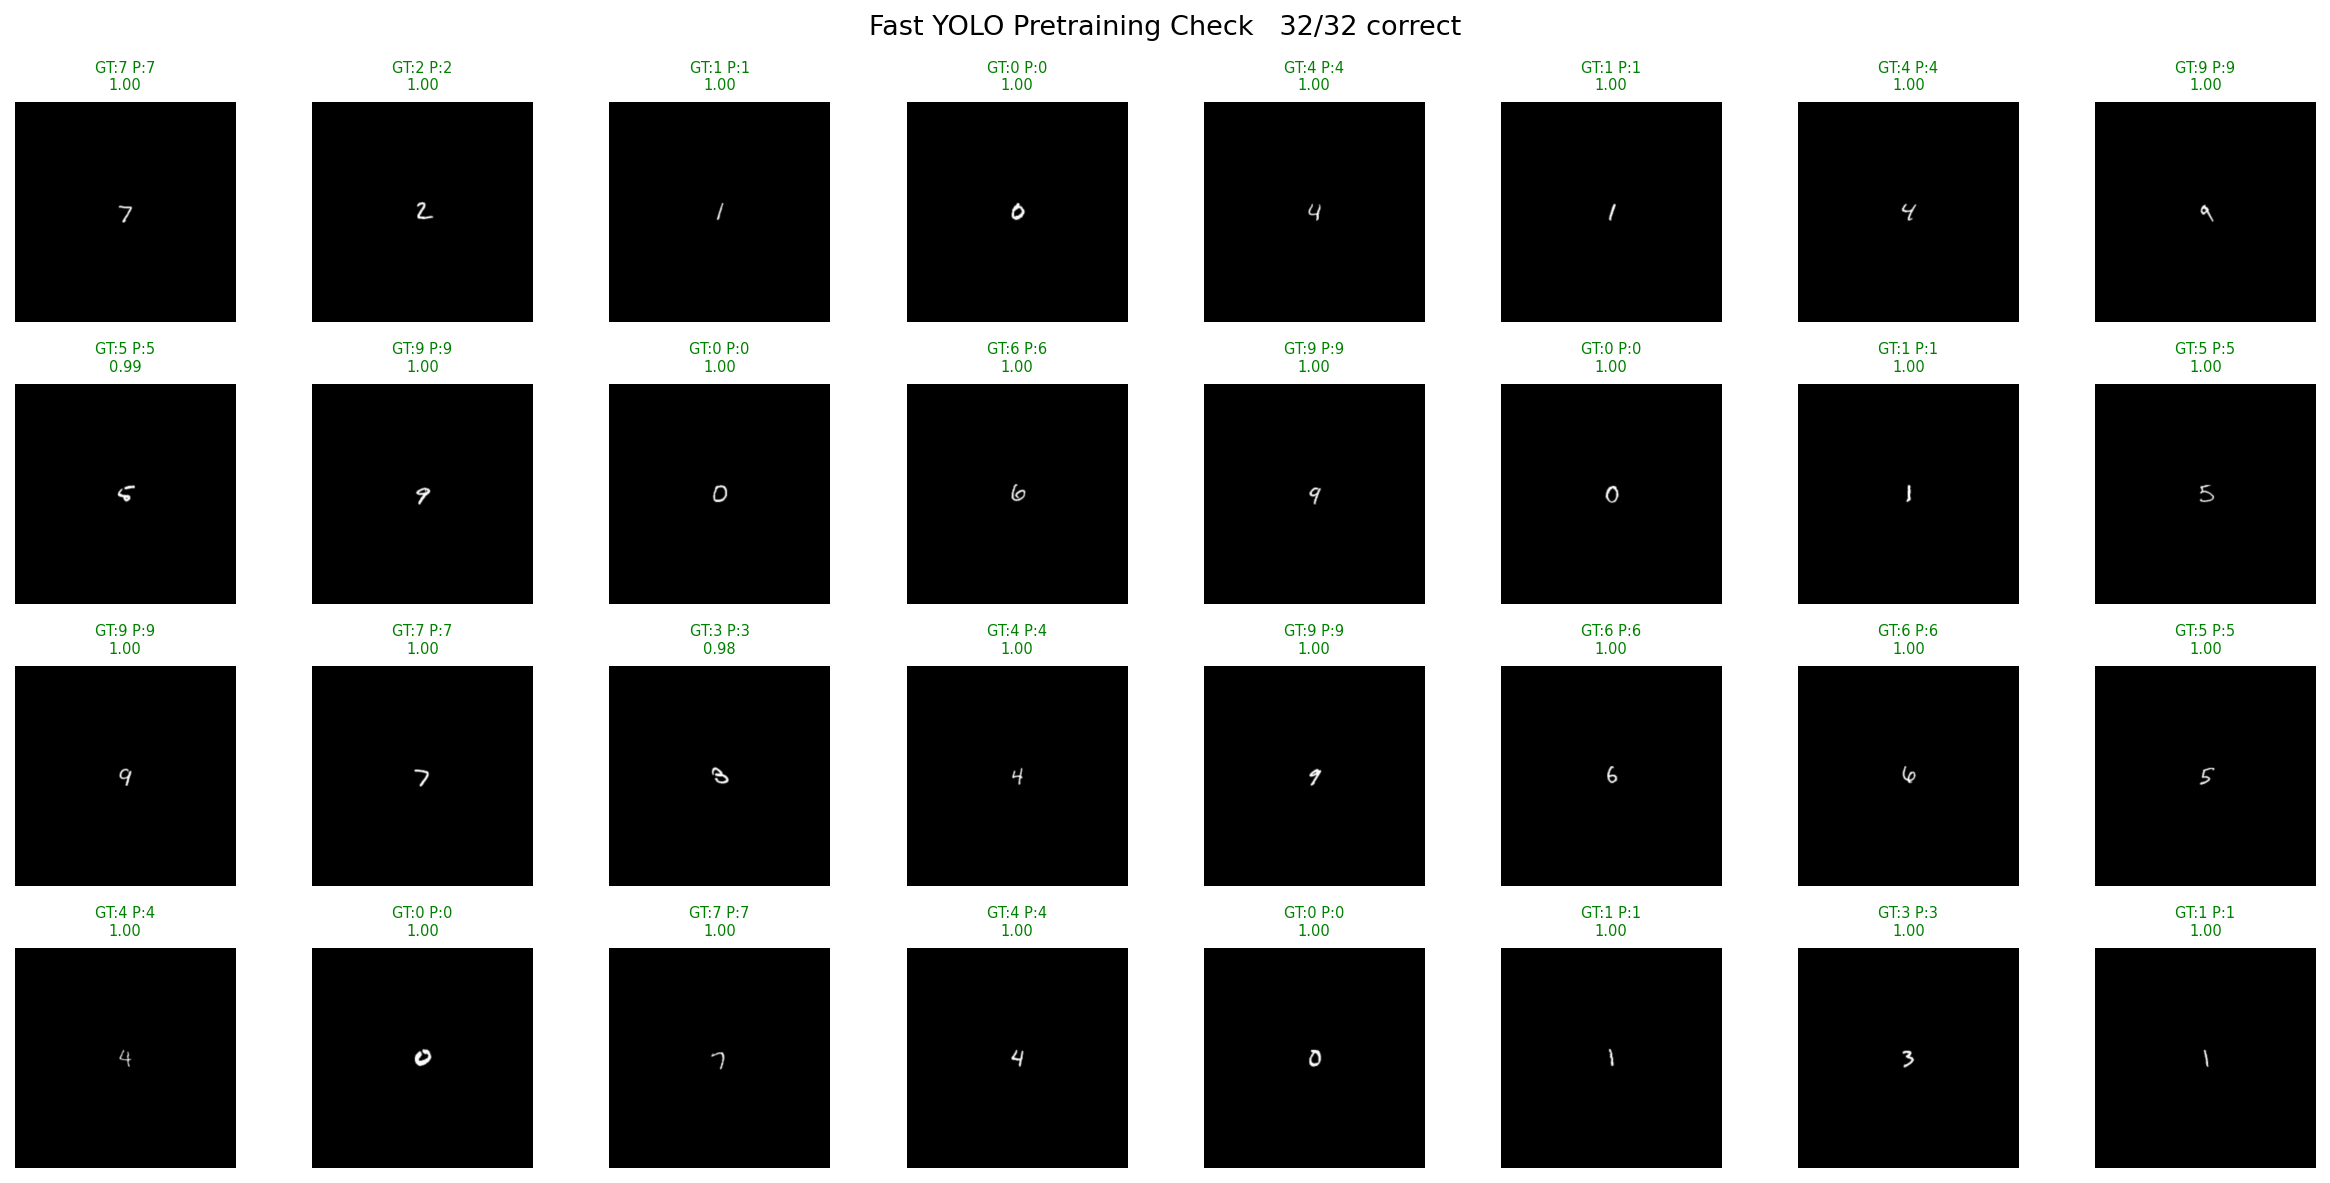

Accuracy on 32 samples: 100.0%


In [58]:
#Pretrain the Fast YOLO backbone on MNIST classification
# Mirrors the paper's ImageNet pretraining stage from Section 4.
# We use the full 60,000 MNIST training images so the backbone
# sees all digit variations: cursive, tilted, thick and thin strokes (this was intentional took more time but was worth it).
# This gives better feature generalisation before detection finetuning
# compared to the 10k subset used in previous runs.
# Training for 5 epochs instead of 10 keeps pretraining time similar
# to before since we have 6x more data per epoch.
# Digits placed at 48x48 on 448x448 canvas matching detection scale
# exactly, fixing the scale mismatch identified in early runs.

from tqdm import tqdm
from torch.utils.data import Subset


class YOLOv1Classifier(nn.Module):
    """
    Fast YOLO backbone with classification head for pretraining.
    Uses same ARCHITECTURE as detection model.
    After pretraining backbone weights are transferred to
    the full YOLOv1 detection model.
    """
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.backbone   = self._build_backbone(in_channels)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((7, 7)),
            nn.Flatten(),
            nn.Linear(1024 * 7 * 7, 4096),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )
        nn.init.kaiming_uniform_(self.classifier[2].weight,
                                  nonlinearity='leaky_relu')
        nn.init.zeros_(self.classifier[2].bias)
        nn.init.kaiming_uniform_(self.classifier[5].weight,
                                  nonlinearity='linear')
        nn.init.zeros_(self.classifier[5].bias)

    def _build_backbone(self, in_channels):
        layers = []
        ch     = in_channels
        for block in ARCHITECTURE:
            if block[0] == "C":
                _, out_ch, k, s, p = block
                layers.append(CNNBlock(ch, out_ch,
                               kernel_size=k, stride=s, padding=p))
                ch = out_ch
            elif block[0] == "M":
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            elif block[0] == "R":
                _, repeated, n = block
                for _ in range(n):
                    for (_, out_ch, k, s, p) in repeated:
                        layers.append(CNNBlock(ch, out_ch,
                                       kernel_size=k, stride=s, padding=p))
                        ch = out_ch
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x


class MNISTClassificationDataset(Dataset):
    """
    Places each MNIST digit at 48x48 center of a 448x448 canvas.
    Matches detection scale exactly so backbone features transfer
    cleanly without any scale mismatch between pretraining and
    detection finetuning stages.
    Raw MNIST images are 28x28 and upscaled via bilinear
    interpolation to 48x48 before placement.
    """
    def __init__(self, mnist_root, train=True):
        mnist           = MNIST(root=mnist_root, train=train,
                                 download=True)
        self.images     = mnist.data.numpy()
        self.labels     = mnist.targets.numpy()
        self.img_size   = 448
        self.digit_size = 48
        self.to_tensor  = transforms.ToTensor()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        digit     = Image.fromarray(self.images[idx]).resize(
                        (self.digit_size, self.digit_size),
                        Image.BILINEAR)
        digit_arr = np.array(digit)
        canvas    = np.zeros((self.img_size, self.img_size),
                              dtype=np.uint8)
        offset    = (self.img_size - self.digit_size) // 2
        canvas[offset:offset+self.digit_size,
               offset:offset+self.digit_size] = digit_arr
        return self.to_tensor(canvas), int(self.labels[idx])


# Use full MNIST datasets, no subsampling
# 60,000 train and 10,000 val so backbone sees all digit variations
# cursive, tilted, thick and thin strokes all represented
print("Loading full MNIST for pretraining...")
clf_train_full = MNISTClassificationDataset(DATA_DIR, train=True)
clf_val_full   = MNISTClassificationDataset(DATA_DIR, train=False)

print(f"Full train set : {len(clf_train_full)}")
print(f"Full val set   : {len(clf_val_full)}")

# full dataset loaders, no subset
clf_train_loader = DataLoader(clf_train_full, batch_size=64,
                               shuffle=True,  num_workers=2,
                               pin_memory=True)
clf_val_loader   = DataLoader(clf_val_full,   batch_size=64,
                               shuffle=False, num_workers=2,
                               pin_memory=True)

print(f"Train batches  : {len(clf_train_loader)}")
print(f"Val batches    : {len(clf_val_loader)}")

clf_model     = YOLOv1Classifier(in_channels=1,
                                   num_classes=10).to(DEVICE)
clf_criterion = nn.CrossEntropyLoss()

total = sum(p.numel() for p in clf_model.parameters())
print(f"Total params   : {total:,}")

# paper uses SGD with momentum and weight decay for pretraining
clf_optimizer = optim.SGD(
    clf_model.parameters(),
    lr           = 1e-2,
    momentum     = 0.9,
    weight_decay = 5e-4,
)

# 5 epochs instead of 10 since each epoch has 6x more batches
# decay at epoch 3 proportionally scaled from previous milestone of 7
clf_scheduler = optim.lr_scheduler.MultiStepLR(
    clf_optimizer, milestones=[3], gamma=0.1)

# 5 epochs covers full MNIST in similar wall time to
# previous 10 epoch subset run
CLF_EPOCHS = 5
best_acc   = 0.0

print(f"\nStarting Fast YOLO backbone pretraining")
print(f"Full MNIST: {len(clf_train_full)} train, "
      f"{len(clf_val_full)} val")
print(f"Epochs: {CLF_EPOCHS}  LR decays at epoch 3\n")

for epoch in range(1, CLF_EPOCHS + 1):
    t0 = time.time()

    clf_model.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    train_bar = tqdm(clf_train_loader,
                     desc=f"Epoch {epoch:02d}/{CLF_EPOCHS} [Train]",
                     leave=False)

    for imgs, labels in train_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        clf_optimizer.zero_grad()
        logits = clf_model(imgs)
        loss   = clf_criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clf_model.parameters(), 10.0)
        clf_optimizer.step()

        train_loss    += loss.item()
        preds          = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)
        train_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100.0 * train_correct / train_total:.2f}%")

    clf_model.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    val_bar = tqdm(clf_val_loader,
                   desc=f"Epoch {epoch:02d}/{CLF_EPOCHS} [Val]  ",
                   leave=False)

    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits       = clf_model(imgs)
            loss         = clf_criterion(logits, labels)
            val_loss    += loss.item()
            preds        = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
            val_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{100.0 * val_correct / val_total:.2f}%")

    clf_scheduler.step()

    train_loss_avg = train_loss / len(clf_train_loader)
    val_loss_avg   = val_loss   / len(clf_val_loader)
    train_acc      = 100.0 * train_correct / train_total
    val_acc        = 100.0 * val_correct   / val_total
    elapsed        = time.time() - t0

    print(f"Epoch {epoch:02d}/{CLF_EPOCHS}  "
          f"lr={clf_optimizer.param_groups[0]['lr']:.2e}  "
          f"time={elapsed:.1f}s  "
          f"train_loss={train_loss_avg:.4f}  "
          f"val_loss={val_loss_avg:.4f}  "
          f"train_acc={train_acc:.2f}%  "
          f"val_acc={val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch'         : epoch,
            'backbone_state': clf_model.backbone.state_dict(),
            'model_state'   : clf_model.state_dict(),
            'val_acc'       : val_acc,
        }, f"{CKPT_DIR}/fastyolo_pretrain_best.pt")
        print(f"  Saved best checkpoint  val_acc={val_acc:.2f}%")

print(f"\nPretraining complete. Best val accuracy: {best_acc:.2f}%")
print(f"Backbone weights saved to "
      f"{CKPT_DIR}/fastyolo_pretrain_best.pt")

# verifying pretraining by visualising 32 random val samples
clf_model.eval()
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes      = axes.flatten()

correct = 0
total   = 32

with torch.no_grad():
    for i in range(total):
        img, true_label = clf_val_full[i]
        img_input = img.unsqueeze(0).to(DEVICE)
        logits    = clf_model(img_input)
        pred      = logits.argmax(dim=1).item()
        conf      = torch.softmax(logits, dim=1).max().item()

        if pred == true_label:
            correct += 1

        ax    = axes[i]
        color = 'green' if pred == true_label else 'red'
        ax.imshow(img.squeeze(0).numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"GT:{true_label} P:{pred}\n{conf:.2f}",
                     color=color, fontsize=7)
        ax.axis('off')

plt.suptitle(f"Fast YOLO Pretraining Check   "
             f"{correct}/{total} correct", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/fastyolo_pretrain_check.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"Accuracy on 32 samples: {100.0*correct/total:.1f}%")

In [36]:
#Fast YOLO Detection Finetuning
# Stage 2 of the paper's pipeline. Pretrained Fast YOLO backbone
# weights are loaded and the full network trains end to end on
# synthetic multi-digit detection scenes.
# All training settings identical to best run (Run 4) except
# architecture which uses 9 conv layers instead of what we used in run 4.

from tqdm import tqdm

def decode_predictions(pred, conf_threshold=0.1, S=7, B=2, C=10):
    boxes     = []
    cell_size = 1.0 / S
    for i in range(S):
        for j in range(S):
            for b in range(B):
                offset = b * 5
                conf   = pred[i, j, offset + 4].item()
                if conf < conf_threshold:
                    continue
                x_cell = pred[i, j, offset + 0].item()
                y_cell = pred[i, j, offset + 1].item()
                w      = pred[i, j, offset + 2].item()
                h      = pred[i, j, offset + 3].item()
                cx     = (j + x_cell) * cell_size
                cy     = (i + y_cell) * cell_size
                x1     = cx - w / 2
                y1     = cy - h / 2
                x2     = cx + w / 2
                y2     = cy + h / 2
                cls_id = pred[i, j, B*5:].argmax().item()
                boxes.append([x1, y1, x2, y2, conf, cls_id])
    return boxes


def compute_iou_pair(box1, box2):
    ix1   = max(box1[0], box2[0])
    iy1   = max(box1[1], box2[1])
    ix2   = min(box1[2], box2[2])
    iy2   = min(box1[3], box2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-8
    return inter / union


def apply_nms(boxes, nms_threshold=0.45):
    if len(boxes) == 0:
        return []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        boxes = [b for b in boxes
                 if compute_iou_pair(best[:4], b[:4]) < nms_threshold]
    return kept


def evaluate_map(model, dataset, conf_threshold=0.1,
                 nms_threshold=0.45, iou_threshold=0.5,
                 S=7, B=2, C=10):
    from collections import defaultdict
    model.eval()
    all_detections   = defaultdict(list)
    all_groundtruths = defaultdict(list)
    image_id         = 0
    loader = DataLoader(dataset, batch_size=16,
                        shuffle=False, num_workers=2)
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs  = imgs.to(DEVICE)
            preds = model(imgs).cpu()
            for i in range(imgs.size(0)):
                pred  = preds[i]
                lbl   = lbls[i]
                boxes = decode_predictions(pred,
                            conf_threshold=conf_threshold,
                            S=S, B=B, C=C)
                boxes = apply_nms(boxes, nms_threshold)
                for box in boxes:
                    x1, y1, x2, y2, conf, cls_id = box
                    all_detections[cls_id].append({
                        'image_id'  : image_id,
                        'confidence': conf,
                        'box'       : [x1, y1, x2, y2],
                    })
                cell_size = 1.0 / S
                for row in range(S):
                    for col in range(S):
                        if lbl[row, col, 4] == 1.0:
                            x_cell = lbl[row, col, 0].item()
                            y_cell = lbl[row, col, 1].item()
                            w      = lbl[row, col, 2].item()
                            h      = lbl[row, col, 3].item()
                            cls_id = lbl[row, col, B*5:].argmax().item()
                            cx     = (col + x_cell) * cell_size
                            cy     = (row + y_cell) * cell_size
                            all_groundtruths[cls_id].append({
                                'image_id': image_id,
                                'box'     : [cx-w/2, cy-h/2,
                                             cx+w/2, cy+h/2],
                                'used'    : False,
                            })
                image_id += 1

    aps        = []
    precisions = []
    recalls    = []
    for cls_id in range(C):
        dets = sorted(all_detections.get(cls_id, []),
                      key=lambda x: x['confidence'], reverse=True)
        gts  = all_groundtruths.get(cls_id, [])
        for gt in gts:
            gt['used'] = False
        tp = []
        fp = []
        for det in dets:
            best_iou = 0
            best_gt  = None
            for gt in gts:
                if gt['image_id'] != det['image_id']:
                    continue
                iou = compute_iou_pair(det['box'], gt['box'])
                if iou > best_iou:
                    best_iou = iou
                    best_gt  = gt
            if (best_iou >= iou_threshold and best_gt
                    and not best_gt['used']):
                tp.append(1)
                fp.append(0)
                best_gt['used'] = True
            else:
                tp.append(0)
                fp.append(1)
        if len(tp) == 0 or len(gts) == 0:
            aps.append(0)
            precisions.append(0)
            recalls.append(0)
            continue
        tp_cs = torch.tensor(tp, dtype=torch.float).cumsum(0)
        fp_cs = torch.tensor(fp, dtype=torch.float).cumsum(0)
        n_gt  = len(gts)
        rec   = tp_cs / (n_gt + 1e-8)
        pre   = tp_cs / (tp_cs + fp_cs + 1e-8)
        ap    = 0
        for thr in torch.linspace(0, 1, 11):
            p = pre[rec >= thr]
            ap += (p.max().item() if len(p) > 0 else 0)
        ap /= 11
        aps.append(ap)
        precisions.append(pre[-1].item())
        recalls.append(rec[-1].item())

    return sum(aps)/len(aps), sum(precisions)/len(precisions), \
           sum(recalls)/len(recalls)


# Build Fast YOLO detection model
model = YOLOv1(in_channels=1, S=S, B=B, C=C).to(DEVICE)

# Load pretrained Fast YOLO backbone
ckpt = torch.load(f"{CKPT_DIR}/fastyolo_pretrain_best.pt",
                   map_location=DEVICE)
model.backbone.load_state_dict(ckpt['backbone_state'])
print(f"Loaded Fast YOLO backbone from epoch {ckpt['epoch']} "
      f"with val_acc={ckpt['val_acc']:.2f}%")

ckpt_w        = list(ckpt['backbone_state'].values())[0]
detect_w      = list(model.backbone.parameters())[0]
weights_match = torch.allclose(ckpt_w.to(DEVICE), detect_w)
print(f"Backbone weights match: {weights_match}")

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}")
print(f"All trainable    : {total == trainable}")

det_train_loader = DataLoader(
    train_dataset, batch_size=16,
    shuffle=True,  num_workers=2, pin_memory=True)
det_val_loader   = DataLoader(
    val_dataset,   batch_size=16,
    shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain : {len(train_dataset)}   batches: {len(det_train_loader)}")
print(f"Val   : {len(val_dataset)}    batches: {len(det_val_loader)}")

criterion = YOLOv1Loss(S=S, B=B, C=C,
                       lambda_coord=LAMBDA_COORD,
                       lambda_noobj=LAMBDA_NOOBJ)

optimizer = optim.SGD(
    model.parameters(),
    lr           = LEARNING_RATE,
    momentum     = MOMENTUM,
    weight_decay = WEIGHT_DECAY,
)

scheduler = get_lr_schedule(optimizer)

DET_EPOCHS    = NUM_EPOCHS
best_val_loss = float('inf')
best_map      = 0.0
det_history   = {
    'train_total': [], 'val_total'  : [],
    'train_xy'   : [], 'train_wh'   : [],
    'train_obj'  : [], 'train_noobj': [],
    'train_cls'  : [], 'lr'         : [],
    'map'        : [], 'precision'  : [],
    'recall'     : [],
}

print(f"\nStarting Fast YOLO finetuning for {DET_EPOCHS} epochs")
print(f"LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  "
      f"lambda_coord={LAMBDA_COORD}  lambda_noobj={LAMBDA_NOOBJ}")
print(f"LR decays at epochs 17 and 23")
print(f"mAP evaluated every epoch\n")

for epoch in range(1, DET_EPOCHS + 1):
    t0 = time.time()

    model.train()
    train_running = {'total': 0., 'xy': 0., 'wh': 0.,
                     'obj': 0., 'noobj': 0., 'cls': 0.}

    train_bar = tqdm(det_train_loader,
                     desc=f"Epoch {epoch:02d}/{DET_EPOCHS} [Train]",
                     leave=False)

    for imgs, labels in train_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        preds        = model(imgs)
        loss, comps  = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        optimizer.step()
        for k in train_running:
            train_running[k] += comps[k]
        train_bar.set_postfix(
            loss=f"{comps['total']:.3f}",
            cls=f"{comps['cls']:.3f}",
            xy=f"{comps['xy']:.3f}")

    model.eval()
    val_running = {'total': 0., 'xy': 0., 'wh': 0.,
                   'obj': 0., 'noobj': 0., 'cls': 0.}

    val_bar = tqdm(det_val_loader,
                   desc=f"Epoch {epoch:02d}/{DET_EPOCHS} [Val]  ",
                   leave=False)

    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds        = model(imgs)
            _, comps     = criterion(preds, labels)
            for k in val_running:
                val_running[k] += comps[k]
            val_bar.set_postfix(loss=f"{comps['total']:.3f}")

    map_score, mean_pre, mean_rec = evaluate_map(
        model, val_dataset,
        conf_threshold = 0.1,
        nms_threshold  = 0.45,
        iou_threshold  = 0.5,
        S=S, B=B, C=C)

    if map_score > best_map:
        best_map = map_score

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    n_train     = len(det_train_loader)
    n_val       = len(det_val_loader)
    train_comps = {k: v / n_train for k, v in train_running.items()}
    val_comps   = {k: v / n_val   for k, v in val_running.items()}

    det_history['train_total'].append(train_comps['total'])
    det_history['val_total'].append(val_comps['total'])
    det_history['train_xy'].append(train_comps['xy'])
    det_history['train_wh'].append(train_comps['wh'])
    det_history['train_obj'].append(train_comps['obj'])
    det_history['train_noobj'].append(train_comps['noobj'])
    det_history['train_cls'].append(train_comps['cls'])
    det_history['lr'].append(current_lr)
    det_history['map'].append(map_score)
    det_history['precision'].append(mean_pre)
    det_history['recall'].append(mean_rec)

    elapsed = time.time() - t0

    print(f"Epoch {epoch:02d}/{DET_EPOCHS}  "
          f"lr={current_lr:.2e}  "
          f"time={elapsed:.1f}s  "
          f"train={train_comps['total']:.3f}  "
          f"val={val_comps['total']:.3f}  "
          f"[xy={train_comps['xy']:.3f}  "
          f"wh={train_comps['wh']:.3f}  "
          f"obj={train_comps['obj']:.3f}  "
          f"noobj={train_comps['noobj']:.3f}  "
          f"cls={train_comps['cls']:.3f}]  "
          f"mAP={map_score*100:.2f}%  "
          f"P={mean_pre*100:.2f}%  "
          f"R={mean_rec*100:.2f}%")

    if val_comps['total'] < best_val_loss:
        best_val_loss = val_comps['total']
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : best_val_loss,
            'map'        : map_score,
        }, f"{CKPT_DIR}/fastyolo_detect_best.pt")
        print(f"  Saved best checkpoint  "
              f"val_loss={best_val_loss:.4f}  "
              f"mAP={map_score*100:.2f}%")

    if epoch % 10 == 0:
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : val_comps['total'],
            'map'        : map_score,
        }, f"{CKPT_DIR}/fastyolo_epoch{epoch:02d}.pt")

print(f"\nFast YOLO finetuning complete.")
print(f"Best val loss : {best_val_loss:.4f}")
print(f"Best mAP@0.5  : {best_map*100:.2f}%")

Loaded Fast YOLO backbone from epoch 5 with val_acc=99.41%
Backbone weights match: True
Total params     : 220,552,020
Trainable params : 220,552,020
All trainable    : True

Train : 16000   batches: 1000
Val   : 3200    batches: 200

Starting Fast YOLO finetuning for 30 epochs
LR=0.001  WD=0.005  lambda_coord=5.0  lambda_noobj=0.5
LR decays at epochs 17 and 23
mAP evaluated every epoch



Epoch 01/30  lr=1.00e-03  time=156.0s  train=7.316  val=5.140  [xy=2.360  wh=0.492  obj=0.055  noobj=0.149  cls=4.260]  mAP=0.23%  P=2.50%  R=0.01%
  Saved best checkpoint  val_loss=5.1395  mAP=0.23%


Epoch 02/30  lr=1.00e-03  time=156.4s  train=5.137  val=4.732  [xy=0.652  wh=0.191  obj=0.128  noobj=0.073  cls=4.092]  mAP=3.32%  P=9.44%  R=0.34%
  Saved best checkpoint  val_loss=4.7318  mAP=3.32%


Epoch 03/30  lr=1.00e-03  time=156.9s  train=4.743  val=4.603  [xy=0.365  wh=0.130  obj=0.187  noobj=0.061  cls=4.000]  mAP=5.12%  P=17.35%  R=5.90%
  Saved best checkpoint  val_loss=4.6026  mAP=5.12%


Epoch 04/30  lr=1.00e-03  time=158.0s  train=4.459  val=4.324  [xy=0.287  wh=0.117  obj=0.190  noobj=0.061  cls=3.805]  mAP=10.71%  P=25.44%  R=16.34%
  Saved best checkpoint  val_loss=4.3239  mAP=10.71%


...

Epoch 26/30  lr=1.00e-05  time=158.9s  train=0.896  val=1.204  [xy=0.151  wh=0.036  obj=0.204  noobj=0.049  cls=0.457]  mAP=86.56%  P=93.03%  R=91.51%
  Saved best checkpoint  val_loss=1.2040  mAP=86.56%


Epoch 27/30  lr=1.00e-05  time=158.6s  train=0.894  val=1.203  [xy=0.150  wh=0.035  obj=0.204  noobj=0.049  cls=0.456]  mAP=86.56%  P=93.03%  R=91.60%
  Saved best checkpoint  val_loss=1.2033  mAP=86.56%


Epoch 28/30  lr=1.00e-05  time=158.6s  train=0.898  val=1.199  [xy=0.149  wh=0.035  obj=0.208  noobj=0.049  cls=0.457]  mAP=86.56%  P=93.07%  R=91.82%
  Saved best checkpoint  val_loss=1.1993  mAP=86.56%


Epoch 29/30  lr=1.00e-05  time=158.8s  train=0.893  val=1.203  [xy=0.149  wh=0.035  obj=0.207  noobj=0.049  cls=0.454]  mAP=86.53%  P=92.87%  R=91.61%


Epoch 30/30  lr=1.00e-05  time=158.4s  train=0.891  val=1.202  [xy=0.148  wh=0.035  obj=0.205  noobj=0.049  cls=0.454]  mAP=86.52%  P=92.93%  R=91.74%

Fast YOLO finetuning complete.
Best val loss : 1.1993
Best mAP@0.5  : 86.59%


Loaded checkpoint  epoch=28  mAP=86.56%


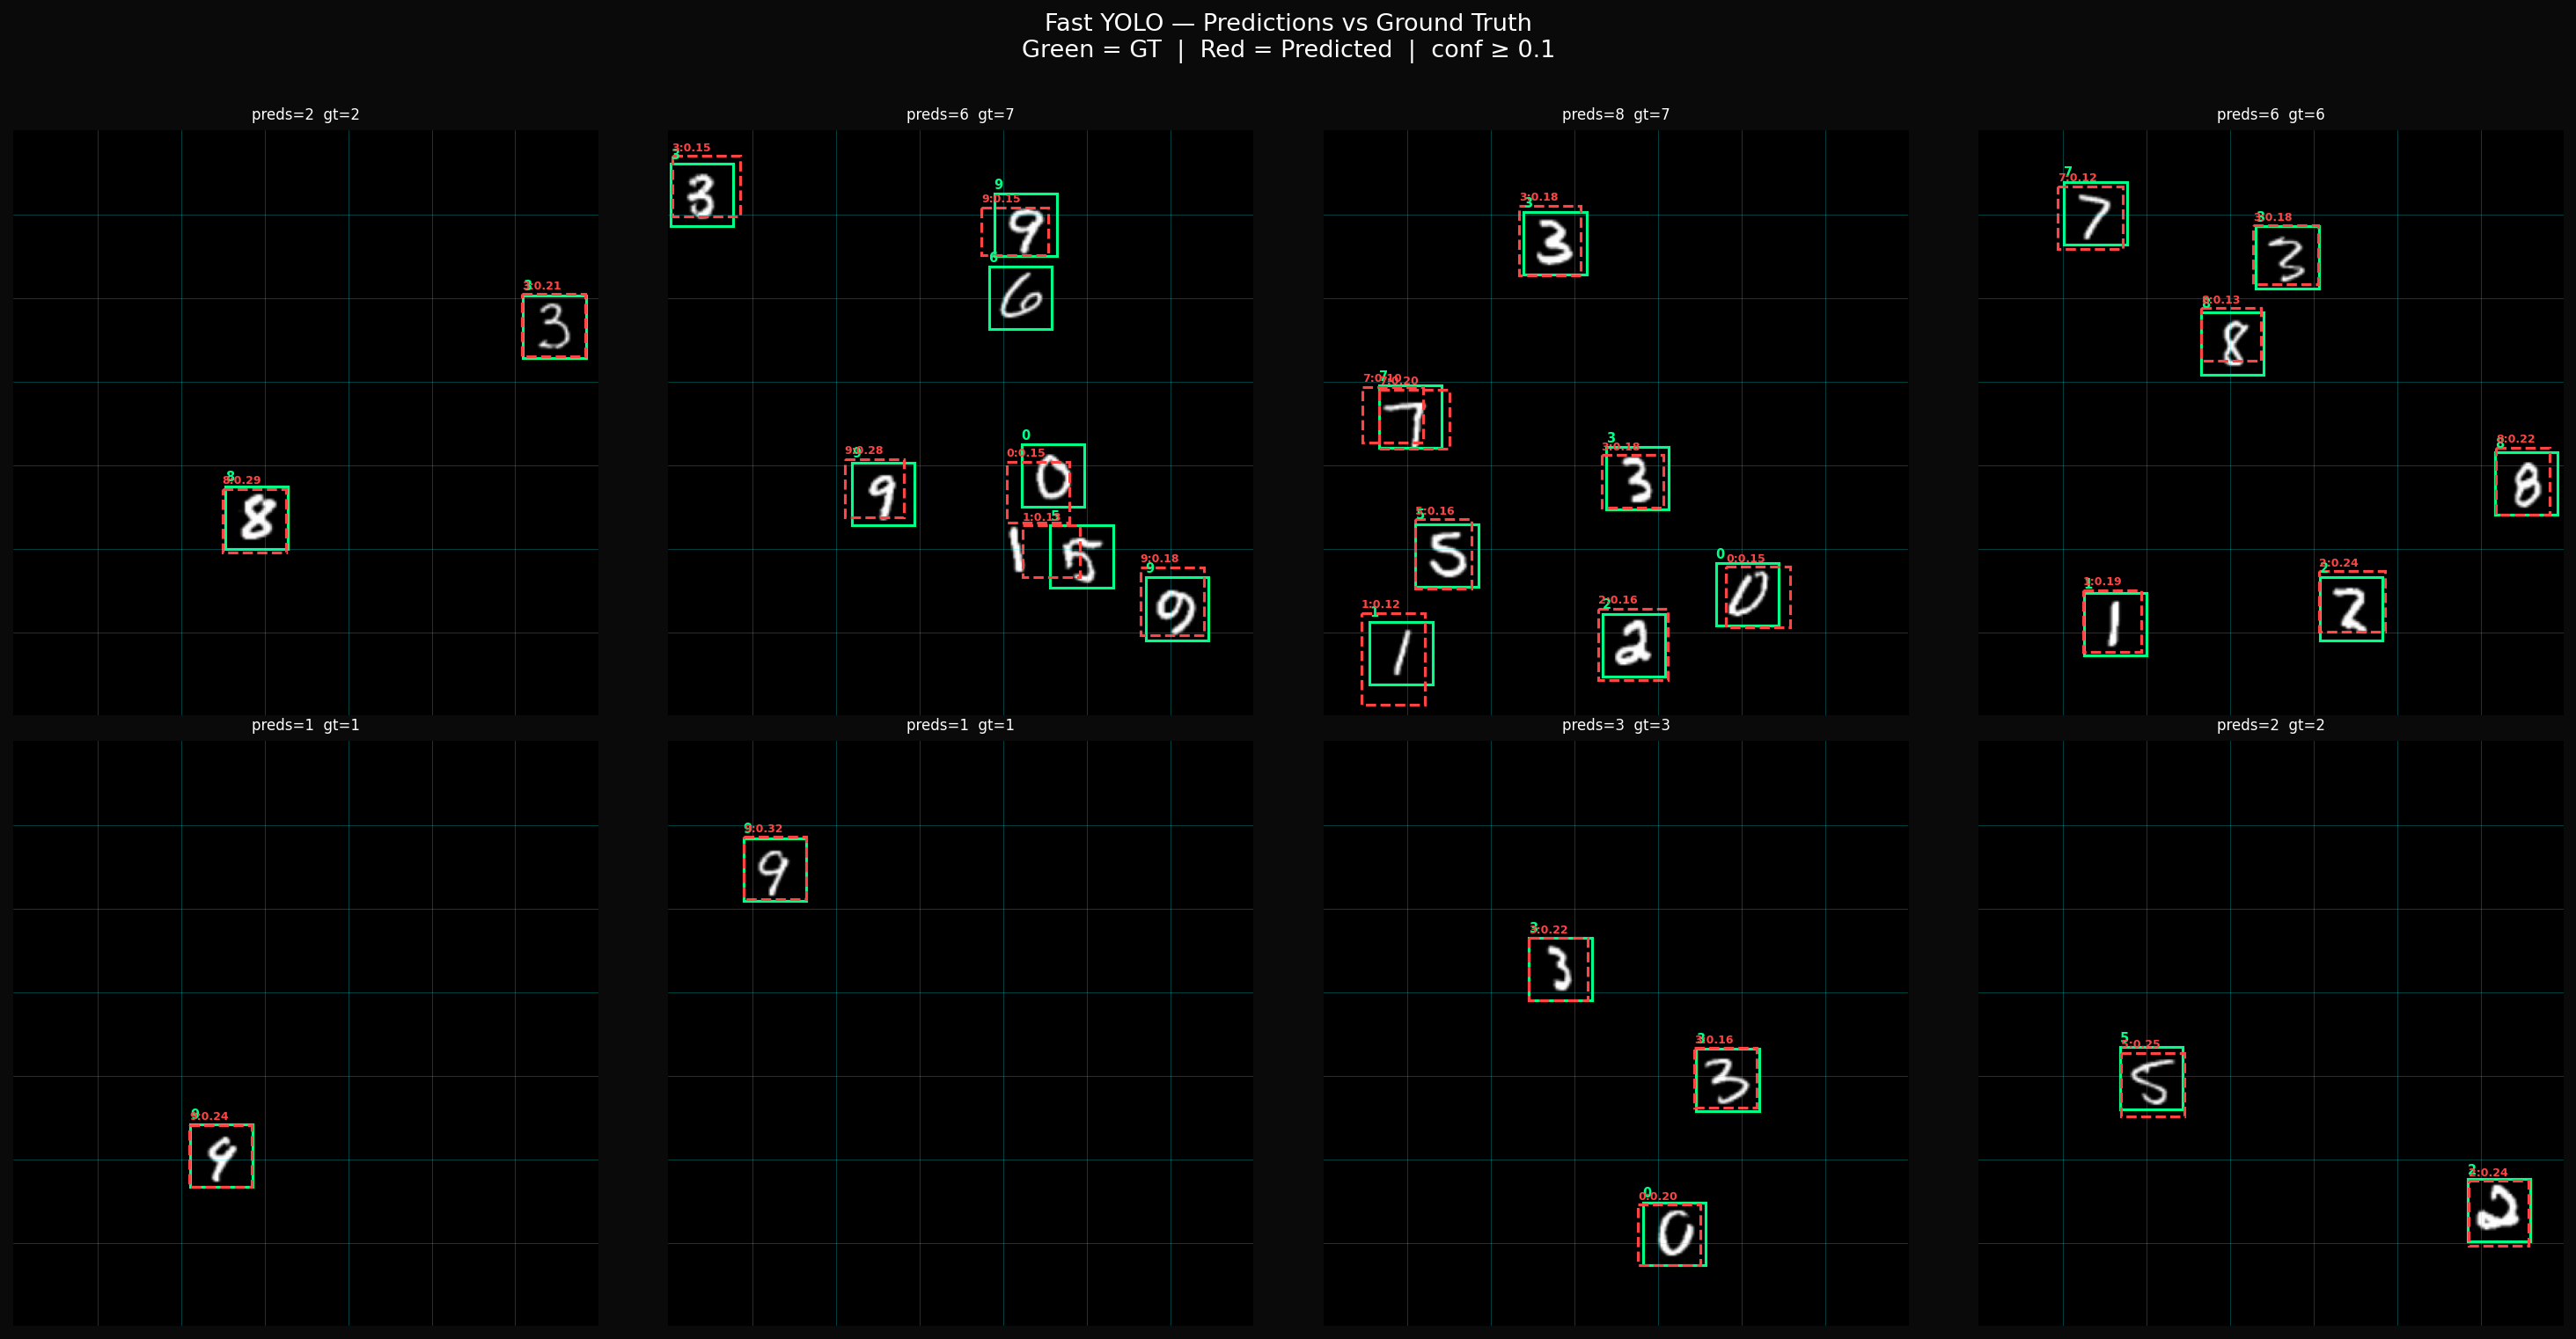

Saved → predictions_vis.png


In [65]:
#Prediction Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random, torch
import numpy as np

#helper funcs
def decode_predictions(output, S=7, B=2, C=10,
                        conf_thresh=0.25, iou_thresh=0.5):
    boxes = []
    output = output.squeeze(0)
    for i in range(S):
        for j in range(S):
            for b in range(B):
                idx  = b * 5
                # apply sigmoid to objectness — raw logit from linear output
                conf = torch.sigmoid(output[i, j, idx + 4]).item()
                if conf < conf_thresh:
                    continue
                bx = (torch.sigmoid(output[i, j, idx + 0]).item() + j) / S
                by = (torch.sigmoid(output[i, j, idx + 1]).item() + i) / S
                bw =  output[i, j, idx + 2].item()
                bh =  output[i, j, idx + 3].item()
                # softmax over class scores
                class_probs = torch.softmax(output[i, j, B*5 : B*5+C], dim=0)
                cls   = class_probs.argmax().item()
                score = conf * class_probs[cls].item()
                if score < conf_thresh:
                    continue
                x1 = (bx - bw/2) * IMG_SIZE
                y1 = (by - bh/2) * IMG_SIZE
                x2 = (bx + bw/2) * IMG_SIZE
                y2 = (by + bh/2) * IMG_SIZE
                boxes.append([x1, y1, x2, y2, score, cls])
    return nms(boxes, iou_thresh)


def iou(b1, b2):
    xi1 = max(b1[0], b2[0]); yi1 = max(b1[1], b2[1])
    xi2 = min(b1[2], b2[2]); yi2 = min(b1[3], b2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def nms(boxes, iou_thresh=0.5):
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        boxes = [b for b in boxes if iou(best, b) < iou_thresh]
    return kept


def decode_gt(label, S=7, B=2, C=10):
    """Decode ground truth tensor to list of [x1,y1,x2,y2,cls]."""
    boxes = []
    label = label.squeeze(0)
    for i in range(S):
        for j in range(S):
            if label[i, j, 4].item() == 1.0:   # obj present
                bx = (label[i, j, 0].item() + j) / S
                by = (label[i, j, 1].item() + i) / S
                bw =  label[i, j, 2].item()
                bh =  label[i, j, 3].item()
                cls = label[i, j, B*5:].argmax().item()
                x1 = (bx - bw/2) * IMG_SIZE
                y1 = (by - bh/2) * IMG_SIZE
                x2 = (bx + bw/2) * IMG_SIZE
                y2 = (by + bh/2) * IMG_SIZE
                boxes.append([x1, y1, x2, y2, cls])
    return boxes


# load best checkpoint 
model = YOLOv1(in_channels=1, S=S, B=B, C=C).to(DEVICE)
ckpt  = torch.load(f"{CKPT_DIR}/fastyolo_detect_best.pt",
                   map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint  epoch={ckpt['epoch']}  "
      f"mAP={ckpt['map']*100:.2f}%")

#  pick 8 random val samples
indices = random.sample(range(len(val_dataset)), 8)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor('#0a0a0a')
fig.suptitle("Fast YOLO — Predictions vs Ground Truth\n"
             "Green = GT  |  Red = Predicted  |  conf ≥ 0.1",
             color='white', fontsize=13, y=1.01)

cell_px = IMG_SIZE / S

for ax, idx in zip(axes.flat, indices):
    img, lbl = val_dataset[idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(DEVICE))[0].cpu()

    # decode predictions — no sigmoid, raw logits, same as Block 7
    boxes = []
    for i in range(S):
        for j in range(S):
            for b in range(B):
                offset = b * 5
                conf   = pred[i, j, offset + 4].item()
                if conf < 0.1:
                    continue
                x_cell = pred[i, j, offset + 0].item()
                y_cell = pred[i, j, offset + 1].item()
                w      = pred[i, j, offset + 2].item()
                h      = pred[i, j, offset + 3].item()
                cx = (j + x_cell) / S
                cy = (i + y_cell) / S
                x1 = cx - w/2;  y1 = cy - h/2
                x2 = cx + w/2;  y2 = cy + h/2
                cls_id = pred[i, j, B*5:].argmax().item()
                boxes.append([x1, y1, x2, y2, conf, cls_id])

    # NMS
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        def iou(a, b):
            ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
            ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            a1=(a[2]-a[0])*(a[3]-a[1]); a2=(b[2]-b[0])*(b[3]-b[1])
            return inter/(a1+a2-inter+1e-8)
        boxes = [b for b in boxes if iou(best[:4], b[:4]) < 0.45]

    # display
    ax.imshow(img.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_facecolor('#0a0a0a')
    ax.axis('off')

    # grid
    for g in range(1, S):
        ax.axhline(g * cell_px, color='cyan', linewidth=0.3, alpha=0.4)
        ax.axvline(g * cell_px, color='cyan', linewidth=0.3, alpha=0.4)

    # ground truth green
    for i in range(S):
        for j in range(S):
            if lbl[i, j, 4] == 1.0:
                x_cell = lbl[i, j, 0].item()
                y_cell = lbl[i, j, 1].item()
                w_norm = lbl[i, j, 2].item()
                h_norm = lbl[i, j, 3].item()
                cls_id = lbl[i, j, B*5:].argmax().item()
                cx_px  = (j + x_cell) * cell_px
                cy_px  = (i + y_cell) * cell_px
                w_px   = w_norm * IMG_SIZE
                h_px   = h_norm * IMG_SIZE
                rect = patches.Rectangle(
                    (cx_px - w_px/2, cy_px - h_px/2), w_px, h_px,
                    linewidth=1.5, edgecolor='#00ff88', facecolor='none')
                ax.add_patch(rect)
                ax.text(cx_px - w_px/2, cy_px - h_px/2 - 4,
                        str(cls_id), color='#00ff88',
                        fontsize=7, fontweight='bold')

    # predictions — red
    for box in kept:
        x1, y1, x2, y2, conf, cls_id = box
        x1_px = x1 * IMG_SIZE;  y1_px = y1 * IMG_SIZE
        w_px  = (x2-x1) * IMG_SIZE;  h_px = (y2-y1) * IMG_SIZE
        rect = patches.Rectangle(
            (x1_px, y1_px), w_px, h_px,
            linewidth=1.5, edgecolor='#ff4444',
            facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(x1_px, y1_px - 4,
                f"{cls_id}:{conf:.2f}", color='#ff4444',
                fontsize=6, fontweight='bold')

    ax.set_title(f"preds={len(kept)}  gt={int(lbl[:,:,4].sum().item())}",
                 color='white', fontsize=8)

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/predictions_vis.png",
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("Saved → predictions_vis.png")

Loaded checkpoint  epoch=28  mAP=86.56%


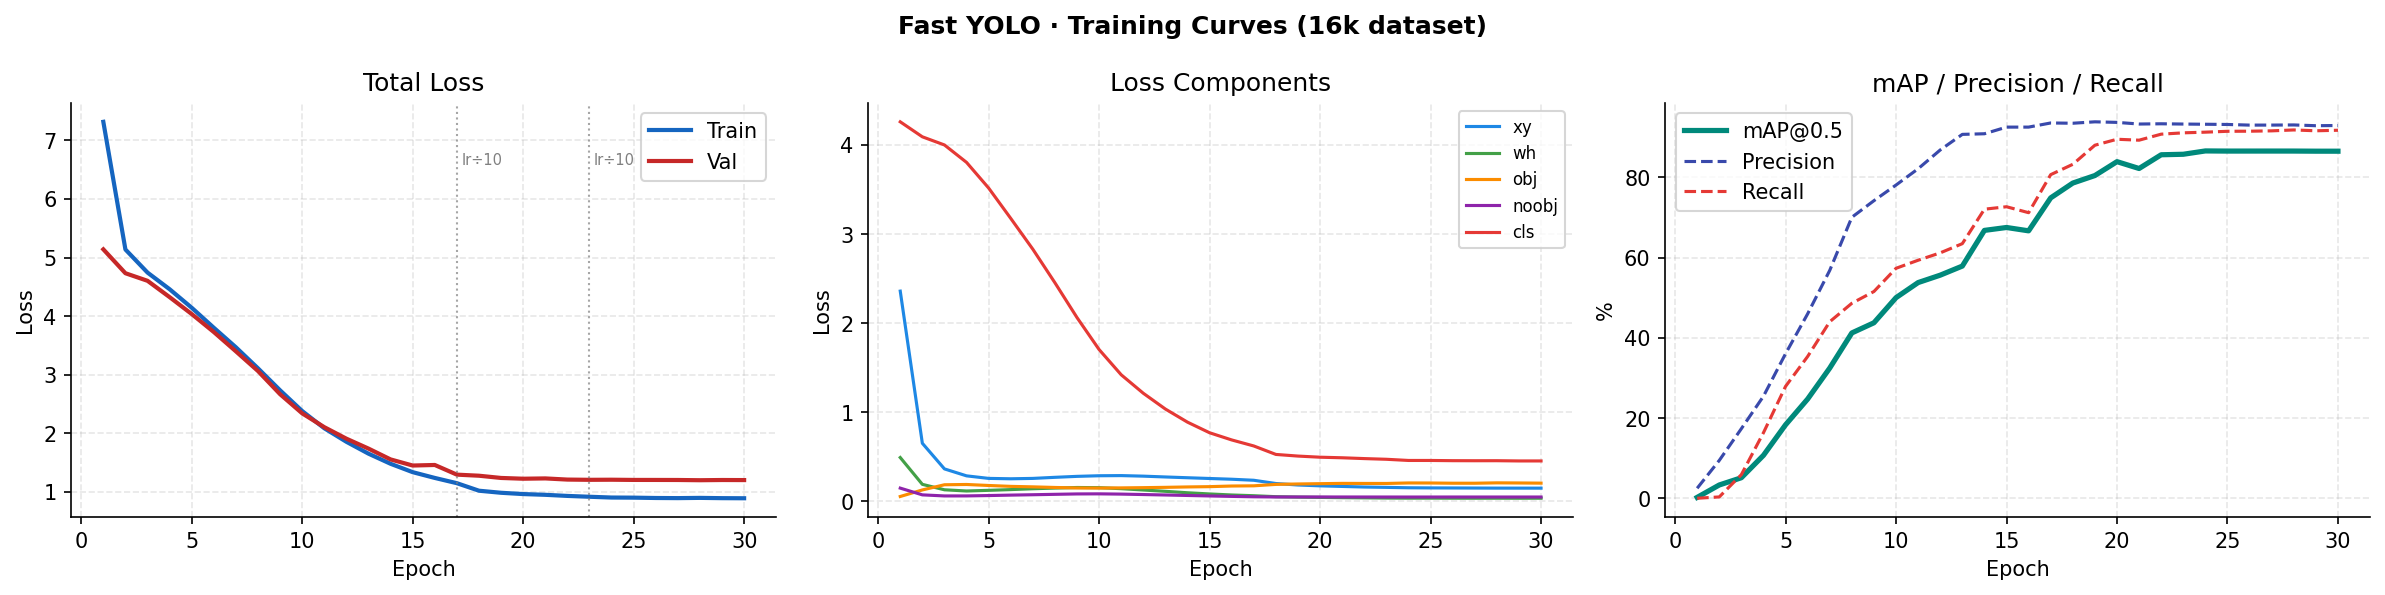

Saved → fig_training_curves.png
Computing per-class AP...


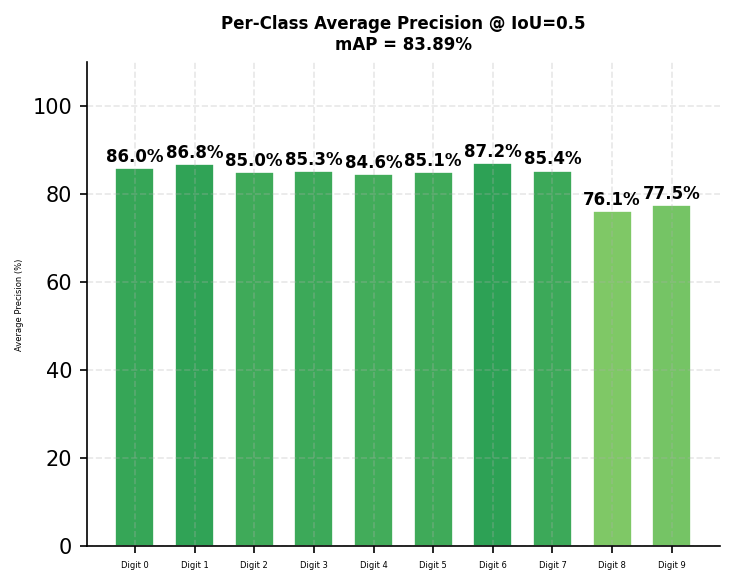

Saved → fig_per_class_ap.png
Building confusion matrix...


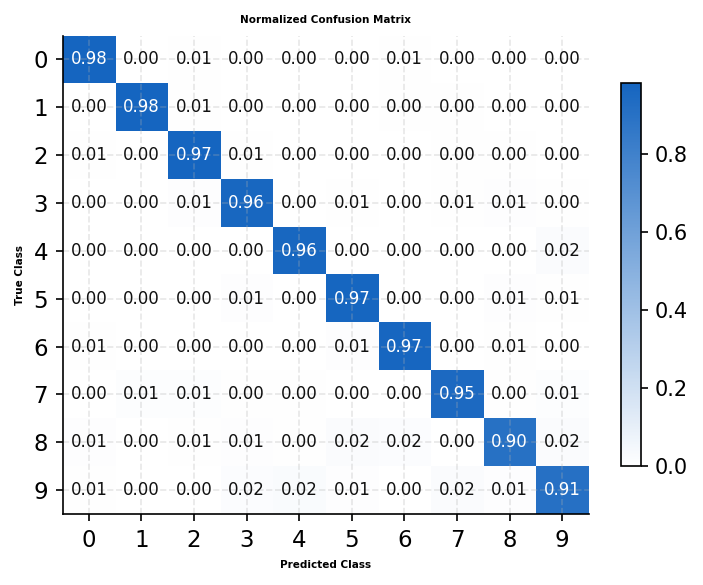

Saved → fig_confusion_matrix.png

           MODEL COMPLEXITY REPORT
Architecture      : Fast YOLO
Input Size        : 1 × 448 × 448
GFLOPs            : 3.71
Total Parameters  : 220,552,020
Backbone Params   : 11,011,968 (5.0%)
Head Params       : 209,540,052 (95.0%)
Best mAP@0.5      : 86.56%
Inference Speed   : 177.26 FPS
Latency           : 5.64 ms/image

All figures saved to:
/kaggle/working/checkpoints


In [57]:

#=Comprehensive Analysis for our yolo

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import torch
import torch.nn as nn
import random
import time

from collections import defaultdict
from torch.utils.data import DataLoader

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 150,
})


# LOAD CHECKPOINT

model = YOLOv1(in_channels=1, S=S, B=B, C=C).to(DEVICE)

ckpt = torch.load(
    f"{CKPT_DIR}/fastyolo_detect_best.pt",
    map_location=DEVICE
)

model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Loaded checkpoint  epoch={ckpt['epoch']}  "
      f"mAP={ckpt['map']*100:.2f}%")
# FIG 1 — TRAINING CURVES

epochs = list(range(1, len(det_history['train_total']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

fig.suptitle(
    "Fast YOLO · Training Curves (16k dataset)",
    fontsize=12,
    fontweight='bold'
)

# TOTAL LOSS

ax = axes[0]

ax.plot(
    epochs,
    det_history['train_total'],
    color='#1565C0',
    lw=2,
    label='Train'
)

ax.plot(
    epochs,
    det_history['val_total'],
    color='#C62828',
    lw=2,
    label='Val'
)

for m in [17, 23]:
    ax.axvline(
        m,
        color='grey',
        lw=1,
        linestyle=':',
        alpha=0.7
    )

    ax.text(
        m + 0.2,
        max(det_history['train_total']) * 0.9,
        'lr÷10',
        fontsize=7,
        color='grey'
    )

ax.set_title('Total Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

# LOSS COMPONENTS

ax = axes[1]

for key, label, color in [
    ('train_xy',    'xy',    '#1E88E5'),
    ('train_wh',    'wh',    '#43A047'),
    ('train_obj',   'obj',   '#FB8C00'),
    ('train_noobj', 'noobj', '#8E24AA'),
    ('train_cls',   'cls',   '#E53935'),
]:
    ax.plot(
        epochs,
        det_history[key],
        lw=1.5,
        label=label,
        color=color
    )

ax.set_title('Loss Components')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
# mAP / PRECISION / RECALL

ax = axes[2]

ax.plot(
    epochs,
    [x * 100 for x in det_history['map']],
    color='#00897B',
    lw=2.5,
    label='mAP@0.5'
)

ax.plot(
    epochs,
    [x * 100 for x in det_history['precision']],
    color='#3949AB',
    lw=1.5,
    linestyle='--',
    label='Precision'
)

ax.plot(
    epochs,
    [x * 100 for x in det_history['recall']],
    color='#E53935',
    lw=1.5,
    linestyle='--',
    label='Recall'
)

ax.set_title('mAP / Precision / Recall')
ax.set_xlabel('Epoch')
ax.set_ylabel('%')
ax.legend()

plt.tight_layout()

plt.savefig(
    f"{CKPT_DIR}/fig_training_curves.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved → fig_training_curves.png")

# PER-CLASS AP EVALUATION

def evaluate_per_class_ap(
    model,
    dataset,
    conf_thresh=0.1,
    nms_thresh=0.45,
    iou_thresh=0.5
):

    model.eval()

    all_dets = defaultdict(list)
    all_gts  = defaultdict(list)

    img_id = 0

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2
    )

    with torch.no_grad():

        for imgs, lbls in loader:

            preds = model(imgs.to(DEVICE)).cpu()

            for i in range(imgs.size(0)):

                # FIXED
                boxes = decode_predictions(preds[i], conf_thresh)

                boxes = apply_nms(boxes, nms_thresh)

              
                # PREDICTIONS
        
                for b in boxes:

                    x1, y1, x2, y2, cf, cl = b

                    all_dets[int(cl)].append({
                        'image_id': img_id,
                        'conf'    : float(cf),
                        'box'     : [x1, y1, x2, y2]
                    })

                
                # GROUND TRUTH
                
                lbl = lbls[i]

                for r in range(S):
                    for c in range(S):

                        if lbl[r, c, 4] == 1.0:

                            xc = (c + lbl[r, c, 0].item()) / S
                            yc = (r + lbl[r, c, 1].item()) / S

                            w = lbl[r, c, 2].item()
                            h = lbl[r, c, 3].item()

                            cl = lbl[r, c, B*5:].argmax().item()

                            all_gts[int(cl)].append({
                                'image_id': img_id,
                                'box'     : [
                                    xc - w/2,
                                    yc - h/2,
                                    xc + w/2,
                                    yc + h/2
                                ],
                                'used': False
                            })

                img_id += 1
    # COMPUTE AP

    aps = []

    for cls_id in range(C):

        dets = sorted(
            all_dets.get(cls_id, []),
            key=lambda x: x['conf'],
            reverse=True
        )

        gts = all_gts.get(cls_id, [])

        for g in gts:
            g['used'] = False

        tp = []
        fp = []

        for det in dets:

            best_iou = 0
            best_gt  = None

            for gt in gts:

                if gt['image_id'] != det['image_id']:
                    continue

                iou = compute_iou_pair(
                    det['box'],
                    gt['box']
                )

                if iou > best_iou:
                    best_iou = iou
                    best_gt  = gt

            if best_iou >= iou_thresh and best_gt \
                    and not best_gt['used']:

                tp.append(1)
                fp.append(0)

                best_gt['used'] = True

            else:
                tp.append(0)
                fp.append(1)

        if len(tp) == 0 or len(gts) == 0:
            aps.append(0)
            continue

        tp_cs = torch.tensor(tp).float().cumsum(0)
        fp_cs = torch.tensor(fp).float().cumsum(0)

        recall = tp_cs / (len(gts) + 1e-8)

        precision = tp_cs / (
            tp_cs + fp_cs + 1e-8
        )

        ap = 0

        for t in torch.linspace(0, 1, 11):

            if (recall >= t).any():
                ap += precision[recall >= t].max().item()

        ap /= 11

        aps.append(ap)

    return aps
# FIG 2 — PER CLASS AP

print("Computing per-class AP...")

per_class_ap = evaluate_per_class_ap(
    model,
    val_dataset
)

fig, ax = plt.subplots(figsize=(5, 4),
    facecolor='white'
)

colors = plt.cm.RdYlGn(per_class_ap)

bars = ax.bar(
    range(C),
    [ap * 100 for ap in per_class_ap],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.65
)

for bar, ap in zip(bars, per_class_ap):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{ap*100:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

ax.set_xticks(range(C))

ax.set_xticklabels(
    [f'Digit {i}' for i in range(C)],
    fontsize=4
)

ax.set_ylabel(
    'Average Precision (%)',
    fontsize=4
)

ax.set_title(
    f'Per-Class Average Precision @ IoU=0.5\n'
    f'mAP = {sum(per_class_ap)/len(per_class_ap)*100:.2f}%',
    fontsize=8,
    fontweight='bold'
)

ax.set_ylim(0, 110)

plt.tight_layout()

plt.savefig(
    f"{CKPT_DIR}/fig_per_class_ap.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved → fig_per_class_ap.png")

# FIG 3 — CONFUSION MATRIX

print("Building confusion matrix...")

conf_matrix = np.zeros((C, C), dtype=int)

loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

model.eval()

with torch.no_grad():

    for imgs, lbls in loader:

        preds = model(imgs.to(DEVICE)).cpu()

        for i in range(imgs.size(0)):

            boxes = decode_predictions(preds[i], 0.1)

            boxes = apply_nms(boxes, 0.45)

            lbl = lbls[i]

            gt_boxes = []

            for r in range(S):
                for c in range(S):

                    if lbl[r, c, 4] == 1.0:

                        xc = (c + lbl[r, c, 0].item()) / S
                        yc = (r + lbl[r, c, 1].item()) / S

                        w = lbl[r, c, 2].item()
                        h = lbl[r, c, 3].item()

                        cl = lbl[r, c, B*5:].argmax().item()

                        gt_boxes.append([
                            xc - w/2,
                            yc - h/2,
                            xc + w/2,
                            yc + h/2,
                            cl
                        ])

            for box in boxes:

                x1, y1, x2, y2, cf, pred_cls = box

                best_iou = 0
                best_gt_cls = None

                for gt in gt_boxes:

                    iou = compute_iou_pair(
                        [x1, y1, x2, y2],
                        gt[:4]
                    )

                    if iou > best_iou:
                        best_iou = iou
                        best_gt_cls = gt[4]

                if best_iou >= 0.5 and best_gt_cls is not None:

                    conf_matrix[
                        int(best_gt_cls)
                    ][
                        int(pred_cls)
                    ] += 1

# NORMALIZED CONFUSION MATRIX

conf_norm = conf_matrix / (
    conf_matrix.sum(axis=1, keepdims=True) + 1e-8
)

fig, ax = plt.subplots(figsize=(5, 4),
    facecolor='white'
)

cmap = LinearSegmentedColormap.from_list(
    'yolo',
    ['#ffffff', '#1565C0']
)

im = ax.imshow(
    conf_norm,
    cmap=cmap,
    aspect='auto'
)

plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(C))
ax.set_yticks(range(C))

ax.set_xticklabels(range(C), fontsize=11)
ax.set_yticklabels(range(C), fontsize=11)

ax.set_xlabel(
    'Predicted Class',
    fontsize=5,
    fontweight='bold'
)

ax.set_ylabel(
    'True Class',
    fontsize=5,
    fontweight='bold'
)

ax.set_title(
    'Normalized Confusion Matrix',
    fontsize=5,
    fontweight='bold'
)

for r in range(C):
    for c in range(C):

        value = conf_norm[r, c]

        ax.text(
            c,
            r,
            f'{value:.2f}',
            ha='center',
            va='center',
            fontsize=8,
            color='white' if value > 0.5 else '#111111'
        )

plt.tight_layout()

plt.savefig(
    f"{CKPT_DIR}/fig_confusion_matrix.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved → fig_confusion_matrix.png")
# GFLOPs + PARAMS

def compute_gflops(model, input_size=(1,1,448,448)):

    total_macs = [0]

    hooks = []

    def conv_hook(m, inp, out):

        b, c_out, h, w = out.shape

        c_in = inp[0].shape[1]

        k = m.kernel_size[0] * m.kernel_size[1]

        macs = b * c_out * h * w * c_in * k

        if m.groups > 1:
            macs //= m.groups

        total_macs[0] += macs

    def fc_hook(m, inp, out):

        total_macs[0] += (
            inp[0].shape[0]
            * m.in_features
            * m.out_features
        )

    for m in model.modules():

        if isinstance(m, nn.Conv2d):
            hooks.append(
                m.register_forward_hook(conv_hook)
            )

        elif isinstance(m, nn.Linear):
            hooks.append(
                m.register_forward_hook(fc_hook)
            )

    dummy = torch.zeros(*input_size).to(DEVICE)

    with torch.no_grad():
        model(dummy)

    for h in hooks:
        h.remove()

    return total_macs[0] * 2 / 1e9

# COMPUTE MODEL COMPLEXITY

gflops = compute_gflops(model)

total_p = sum(
    p.numel() for p in model.parameters()
)

back_p = sum(
    p.numel() for p in model.backbone.parameters()
)

head_p = total_p - back_p

# INFERENCE SPEED BENCHMARK

dummy = torch.randn(1,1,448,448).to(DEVICE)

for _ in range(20):
    _ = model(dummy)

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.time()

runs = 100

for _ in range(runs):
    _ = model(dummy)

if torch.cuda.is_available():
    torch.cuda.synchronize()

end = time.time()

fps = runs / (end - start)

ms = 1000 / fps

# FINAL REPORT

print("\n" + "="*55)
print("           MODEL COMPLEXITY REPORT")


print(f"Architecture      : Fast YOLO")
print(f"Input Size        : 1 × 448 × 448")
print(f"GFLOPs            : {gflops:.2f}")
print(f"Total Parameters  : {total_p:,}")

print(f"Backbone Params   : {back_p:,} "
      f"({back_p/total_p*100:.1f}%)")

print(f"Head Params       : {head_p:,} "
      f"({head_p/total_p*100:.1f}%)")

print(f"Best mAP@0.5      : {ckpt['map']*100:.2f}%")

print(f"Inference Speed   : {fps:.2f} FPS")

print(f"Latency           : {ms:.2f} ms/image")

print("="*55)

print("\nAll figures saved to:")
print(CKPT_DIR)

Found: 3 missing, 3 wrong class, 3 low confidence


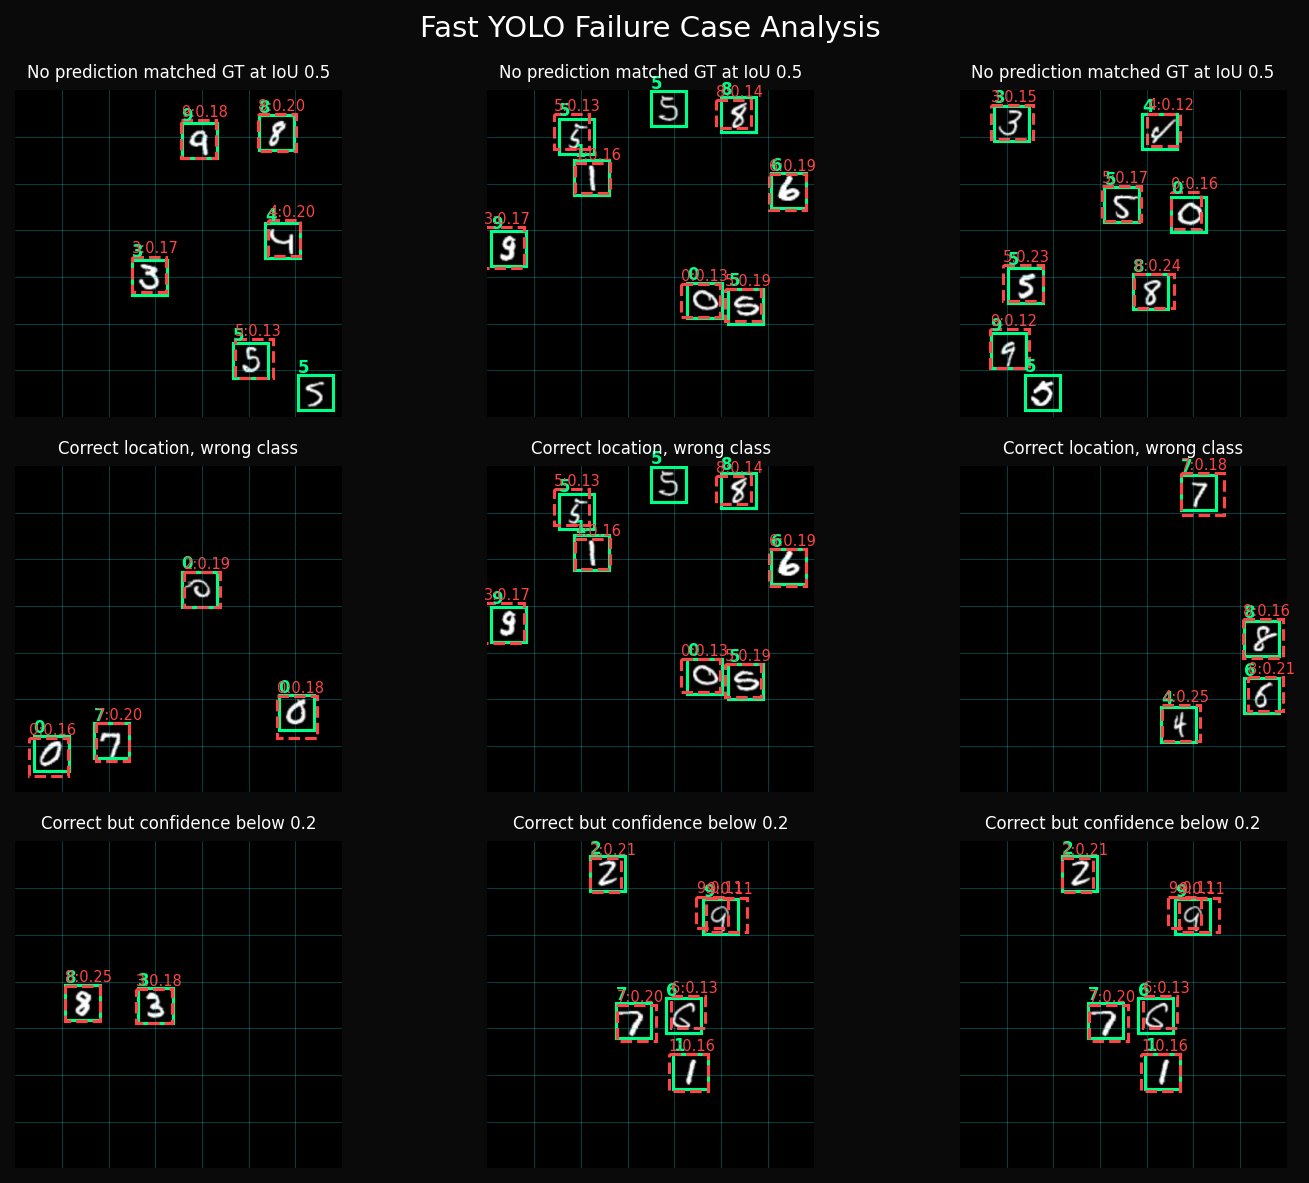

Saved failure_analysis.png


In [67]:
# Block 11: Failure Case Analysis

ckpt = torch.load(f"{CKPT_DIR}/fastyolo_detect_best.pt",
                   map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

def get_boxes(pred):
    boxes = []
    for i in range(S):
        for j in range(S):
            for b in range(B):
                offset = b * 5
                conf   = pred[i, j, offset + 4].item()
                if conf < 0.1:
                    continue
                x_cell = pred[i, j, offset + 0].item()
                y_cell = pred[i, j, offset + 1].item()
                w      = pred[i, j, offset + 2].item()
                h      = pred[i, j, offset + 3].item()
                cx = (j + x_cell) / S
                cy = (i + y_cell) / S
                x1 = cx - w/2
                y1 = cy - h/2
                x2 = cx + w/2
                y2 = cy + h/2
                cls_id = pred[i, j, B*5:].argmax().item()
                boxes.append([x1, y1, x2, y2, conf, cls_id])
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        boxes = [b for b in boxes
                 if compute_iou_pair(best[:4], b[:4]) < 0.45]
    return kept


def get_gt(lbl):
    gt_boxes = []
    cell_size = 1.0 / S
    for i in range(S):
        for j in range(S):
            if lbl[i, j, 4] == 1.0:
                x_cell = lbl[i, j, 0].item()
                y_cell = lbl[i, j, 1].item()
                w      = lbl[i, j, 2].item()
                h      = lbl[i, j, 3].item()
                cls_id = lbl[i, j, B*5:].argmax().item()
                cx     = (j + x_cell) * cell_size
                cy     = (i + y_cell) * cell_size
                gt_boxes.append({
                    'box'    : [cx-w/2, cy-h/2, cx+w/2, cy+h/2],
                    'cls_id' : cls_id,
                })
    return gt_boxes


missing   = []
wrong_cls = []
low_conf  = []

for idx in range(len(val_dataset)):
    img, lbl = val_dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(DEVICE))[0].cpu()

    boxes    = get_boxes(pred)
    gt_boxes = get_gt(lbl)

    for gt in gt_boxes:
        best_iou  = 0
        best_pred = None
        for box in boxes:
            iou = compute_iou_pair(gt['box'], box[:4])
            if iou > best_iou:
                best_iou  = iou
                best_pred = box

        if best_iou < 0.5:
            if len(missing) < 3:
                missing.append((idx, img, lbl, boxes, gt))
        elif best_pred is not None and best_pred[5] != gt['cls_id']:
            if len(wrong_cls) < 3:
                wrong_cls.append((idx, img, lbl, boxes, gt, best_pred))
        elif best_pred is not None and best_pred[4] < 0.2:
            if len(low_conf) < 3:
                low_conf.append((idx, img, lbl, boxes, gt, best_pred))

    if len(missing) >= 3 and len(wrong_cls) >= 3 \
            and len(low_conf) >= 3:
        break

print(f"Found: {len(missing)} missing, "
      f"{len(wrong_cls)} wrong class, "
      f"{len(low_conf)} low confidence")

fig, axes = plt.subplots(3, 3, figsize=(10, 8))
fig.patch.set_facecolor('#0a0a0a')
categories = [
    (missing,   'Missing Detection',    'No prediction matched GT at IoU 0.5'),
    (wrong_cls, 'Wrong Classification', 'Correct location, wrong class'),
    (low_conf,  'Low Confidence',       'Correct but confidence below 0.2'),
]

cell_px = IMG_SIZE / S

for row, (cases, title, desc) in enumerate(categories):
    for col in range(3):
        ax = axes[row][col]
        ax.set_facecolor('#0a0a0a')
        ax.axis('off')

        if col >= len(cases):
            continue

        case = cases[col]
        idx, img, lbl, boxes, gt = case[0], case[1], \
                                    case[2], case[3], case[4]

        ax.imshow(img.squeeze(0).numpy(), cmap='gray',
                  vmin=0, vmax=1)

        for g in range(1, S):
            ax.axhline(g * cell_px, color='cyan',
                       linewidth=0.3, alpha=0.4)
            ax.axvline(g * cell_px, color='cyan',
                       linewidth=0.3, alpha=0.4)

        for i in range(S):
            for j in range(S):
                if lbl[i, j, 4] == 1.0:
                    x_cell = lbl[i, j, 0].item()
                    y_cell = lbl[i, j, 1].item()
                    w_norm = lbl[i, j, 2].item()
                    h_norm = lbl[i, j, 3].item()
                    cls_id = lbl[i, j, B*5:].argmax().item()
                    cx_px  = (j + x_cell) * cell_px
                    cy_px  = (i + y_cell) * cell_px
                    w_px   = w_norm * IMG_SIZE
                    h_px   = h_norm * IMG_SIZE
                    rect   = patches.Rectangle(
                        (cx_px-w_px/2, cy_px-h_px/2), w_px, h_px,
                        linewidth=1.5, edgecolor='#00ff88',
                        facecolor='none')
                    ax.add_patch(rect)
                    ax.text(cx_px-w_px/2, cy_px-h_px/2-4,
                            str(cls_id), color='#00ff88',
                            fontsize=8, fontweight='bold')

        for box in boxes:
            x1, y1, x2, y2, conf, cls_id = box
            rect = patches.Rectangle(
                (x1*IMG_SIZE, y1*IMG_SIZE),
                (x2-x1)*IMG_SIZE, (y2-y1)*IMG_SIZE,
                linewidth=1.5, edgecolor='#ff4444',
                linestyle='--', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1*IMG_SIZE, y1*IMG_SIZE-5,
                    f"{cls_id}:{conf:.2f}",
                    color='#ff4444', fontsize=7)

        if col == 0:
            ax.set_ylabel(title, color='white',
                          fontsize=10, fontweight='bold')
        ax.set_title(desc, color='white', fontsize=8)

plt.suptitle("Fast YOLO Failure Case Analysis",
             color='white', fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/failure_analysis.png",
            dpi=120, bbox_inches='tight',
            facecolor='#0a0a0a')
plt.show()
print("Saved failure_analysis.png")